# Étude des performances des estimateurs de RTF pour l'enregistrement de la source en mouvement 

DATE : 22:10/2025

## Motivation 

Les deux estimateurs CS et CS-EVD présentent des performances identiques dans le cas des enregistrements des positions statiques. 

Pour l'enregistrement de la source en mouvement le signal d'une durée $T \approx 270$ s est segmenté en petites fenêtres d'une durée $T_w = n_w * T_{R}$ où $T_{R} = 1$ s est la période de répétition du chirp LFM. Dans ce cas, l'estimation des vecteurs de RTFs est dégradée (angle hermitien plus important) pour les deux méthodes CS et CS-EVD par rapport au cas statique. Néanmoins, l'estimateur CS présente des performances supérieures avec un angle hermitien plus faible et permet de localiser la source au passage des positions P1 à P6, ce n'est pas le cas avec la méthode CS-EVD. 

Deux hypothèses pour expliquer cette différence ont été avancées : 

* 1) Influence de la durée du signal : 

La durée des fenêtres utilisées conditionne le nombre $L$ de segment disponible pour l'estimation des matrices de covariances : 
   
$$ L = \frac{T f_s - n_{stft} + \alpha_{ov} n_{stft}}  {\alpha_{ov} n_{stft}} $$

La taille des fenêtres STFT $n_{stft}$ doit être suffisamment grande devant la durée de la réponse impulsionnelle pour garantir l'hypothèse de fonction de tranfert multiplicative. 

Pour des courtes fenêtres $T_w$ (typiquement $n_w \in  [2, 3]$ et donc $T_w \in  [2, 3]$s), le faible nombre $L$ de segments disponibles peut engendrer des erreurs d'estimations importantes. 

L'estimateur Sample Covariance Matrix (SCM) utilisé ici :
    
$$ R_x = \frac{1}{K} \sum_{k=1}^{K} \mathbf{x_k} \mathbf{x_k}^H $$

est l'estimateur du maximum de vraisemblance dans le cas où les $(x_1, ..., x_K)$ un K-échantillons de vecteurs indépendants gaussiens complexes ([1] p.20, voir également [2] p. 176 sur le sujet). En présence de valeurs atypiques ou d'une distribution qui s'éloigne de la gaussiannité cet estimateur est peu robuste et l'estimation de paramètres statistique de la matrice tels que les valeurs propres peu ne pas être fiable.

* 2) Effet Doppler : 

En raison de la géométrie du dispositif chacun des capteurs peut expérimenter un décalage Doppler différent ce qui viole notre modèle de signal : 

$$ \mathbf{x}[l, k] = \mathbf{h}[k] s[l, k] + \mathbf{v}[l, k] $$

où le terme source est identique pour chacun des signaux. 

Cette seconde hypothèse sera étudiée dans un autre Notebook dédié. 

## Démarche 

Afin d'étudier l'hypothèse 1 on souhaite étudier les performances de l'estimateur de la matrice de covariance ainsi que les performances des estimateurs CS et CS-EVD associés. Pour ce faire, on procède par étapes : 

* Choix des tailles de fenêtres à tester 
* Calcul des paramètres STFT optimaux pour la plus petite fenêtre possible (cas le plus défavorable) 
* Comparaison des matrices de covariances Rx, Rv, Rz estimées pour chacune des tailles de fenêtre, la matrice de covariance de référence est celle obtenu pour l'ensemble du signal (10 émissions = 10 s + 4.6 s de silence -> 14.6 s)
* Comparaison des valeurs propres / vecteurs propres de la matrice Rz. 
* Comparaison des RTFs estimés 


## Références 

[1] Mélanie Mahot. Estimation robuste de la matrice de covariance en traitement du signal. Autre. École normale supérieure de Cachan - ENS Cachan, 2012.

[2] Capon, J. (1983). Maximum-likelihood spectral estimation. In S. Haykin (Ed.), Nonlinear Methods of Spectral Analysis (pp. 155–179). Springer Berlin Heidelberg. https://doi.org/10.1007/3-540-12386-5_12


In [1]:
import os 
import sys 
import numpy as np 
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt  

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from scipy.linalg import eigh

from misc import progression_bar
from real_data_analysis.fiberscope_20.src import params 
from real_data_analysis.fiberscope_20.src.utils import optimum_stft_params
from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager
from real_data_analysis.fiberscope_20.src.fiberscope_recording import FiberscopeSweep1, FiberscopeSweep2, FiberscopeDynamicRecording
from propa.rtf.rtf_utils import D_hermitian_angle_fast, normalize_metric_contrast

from publication.publication_figure import color

# Etape 1 : définition des paramètres de l'étude 

## Paramètres généraux 

In [2]:
# Reference hydrophone
h_index_ref = 5     # H5 (assumed to be the receiver with the largest SNR)

rtf_estimators = ["cs", "cs-evd"]

# Static recordings to use
fs_sweep = FiberscopeSweep1()
static_records = fs_sweep.records_N1

# Usefull path
root_data = os.path.join(params.root_data, "etude_perf", "duration_influence")
root_img = os.path.join(params.root_img,  "etude_perf", "duration_influence")

# Folder to store output datasets
root_results = os.path.join(root_data, "results")
sliced_data_folder = os.path.join(root_results, "sliced_data")

# Folder to store temporary files
root_tmp = os.path.join(root_data, "tmp")
# stft_twmin_params folder
stft_twmin_params_folder = os.path.join(root_img, "stft_params_Twmin")
# Covariance matrix folder
csdm_folder = os.path.join(root_img, "csdm")
csdm_subfolders = {rtf_e: {rec: os.path.join(csdm_folder, rtf_e, rec) for rec in static_records} for rtf_e in rtf_estimators}
csdm_subfolders_list = [csdm_subfolders[rtf_e][rec] for rtf_e in rtf_estimators  for rec in static_records]

# rtf folder
rtf_folder = os.path.join(root_img, "rtf")
rtf_subfolders = {rtf_e: {rec: os.path.join(rtf_folder, rtf_e, rec) for rec in static_records} for rtf_e in rtf_estimators}
rtf_subfolders_list = [rtf_subfolders[rtf_e][rec] for rtf_e in rtf_estimators  for rec in static_records]
# 

roots = (
    [
        root_data,
        root_img,
        root_results,
        sliced_data_folder,
        root_tmp,
        stft_twmin_params_folder,
    ]
    + csdm_subfolders_list
    + rtf_subfolders_list
)
for root in roots: 
    if not os.path.exists(root):
        os.makedirs(root)


# Fiberscope manager
fsm = FiberscopeManager(
    root_processed_data=root_data,
    h_index_ref=h_index_ref,
    plot_feature=False,      
)

# Signal repetition period
Tr = fs_sweep.interp_pulse_period
# Number of LFM emitted
n_lfm = fs_sweep.n_sweep

# Window lengths to test
nw_min = 1
Tw_min = nw_min * Tr  # Minimum duration to consider 
Tw = np.array([Tw_min + nwi * Tr for nwi in range(nw_min, n_lfm) ]) 

# Signal props
data_fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\static\09-10-2024T10-34-58-394627_P1_N1_Sweep_34.nc"
data = xr.open_dataset(data_fpath)     
fs = data.fs
ts = 1 / fs 
t_max_static = data.time.max().values

# Idx of the reference receiver
idx_rcv_ref = np.argmin(
    np.abs(data.h_index.values - h_index_ref)
)  # Index of hydrophone might not be sorted or not start at 0

In [3]:
dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": True,
    "apply_median": False,
}

In [4]:
# Define the order based on the source position : from closest to farthest
dict_th_pos = params.dict_th_pos
all_dists = np.array([dict_th_pos[pos] for pos in dict_th_pos.keys()])
idx_pos_sort = np.argsort(all_dists)
src_labels = list(dict_th_pos.keys())
src_label_sorted = [src_labels[i] for i in idx_pos_sort]
all_dists_sorted = all_dists[idx_pos_sort]

## Flags
Définition de booléens pour contrôler les cellules à exécuter. Dans le cas où les cellules ne sont pas exécuter l'analyse est faite à partir des résultats précédemment enregistrés. 

In [5]:
run_minimisation = False
plot_minimisation_results = True
run_sliced_rtf_computation = False
plot_tw_slice_rtf_results = True

# Etape 2 : estimation des paramètres STFT optimaux pour la plus petite fenêtre d'étude 

On considère le cas le plus défavorable, c'est-à-dire le cas où le nombre L de snapshots disponible pour l'estimation des CSDM est le plus faible.  

In [6]:
if run_minimisation:
    theta_datasets = optimum_stft_params(
        fs_sweep=fs_sweep,
        fsm=fsm,
        fs=fs,
        root_results=root_results,
        root_tmp=root_tmp,
        signal_duration=1,
        rtf_estimators=["cs", "cs-evd"],
        h_index_ref=h_index_ref, 
        idx_rcv_ref=idx_rcv_ref,
        theta_statistics="mean",
    )
else:
    theta_datasets = {rtf_e: None for rtf_e in rtf_estimators}
    for rtf_e in rtf_estimators:
        # Define the file path to save results
        res_fpath = os.path.join(
            root_results, f"theta_all_static_pos_Tw{Tw_min}_{rtf_e}.nc"
        )

        # Load data
        xr_theta = xr.open_dataset(res_fpath)
        # Store in dict
        theta_datasets[rtf_e] = xr_theta

## Affichage des résultats pour le choix du couple de paramètres optimaux 

In [7]:
# Compute usefull quantities
theta_all_pos = {rtf_e: theta_datasets[rtf_e].theta.values for rtf_e in rtf_estimators}
theta_mean_over_pos = {rtf_e: theta_datasets[rtf_e].theta.mean(dim="pos_id").values for rtf_e in rtf_estimators}
theta_med_over_pos = {rtf_e: theta_datasets[rtf_e].theta.median(dim="pos_id").values for rtf_e in rtf_estimators} 
theta_sum_over_pos = {
    rtf_e: theta_datasets[rtf_e].theta.sum(dim="pos_id").values
    for rtf_e in rtf_estimators
}

n_stft_pow2 = np.unique(theta_datasets["cs"].n_stft_pow2.values)
ov_factors = np.unique(theta_datasets["cs"].alpha_ov.values)

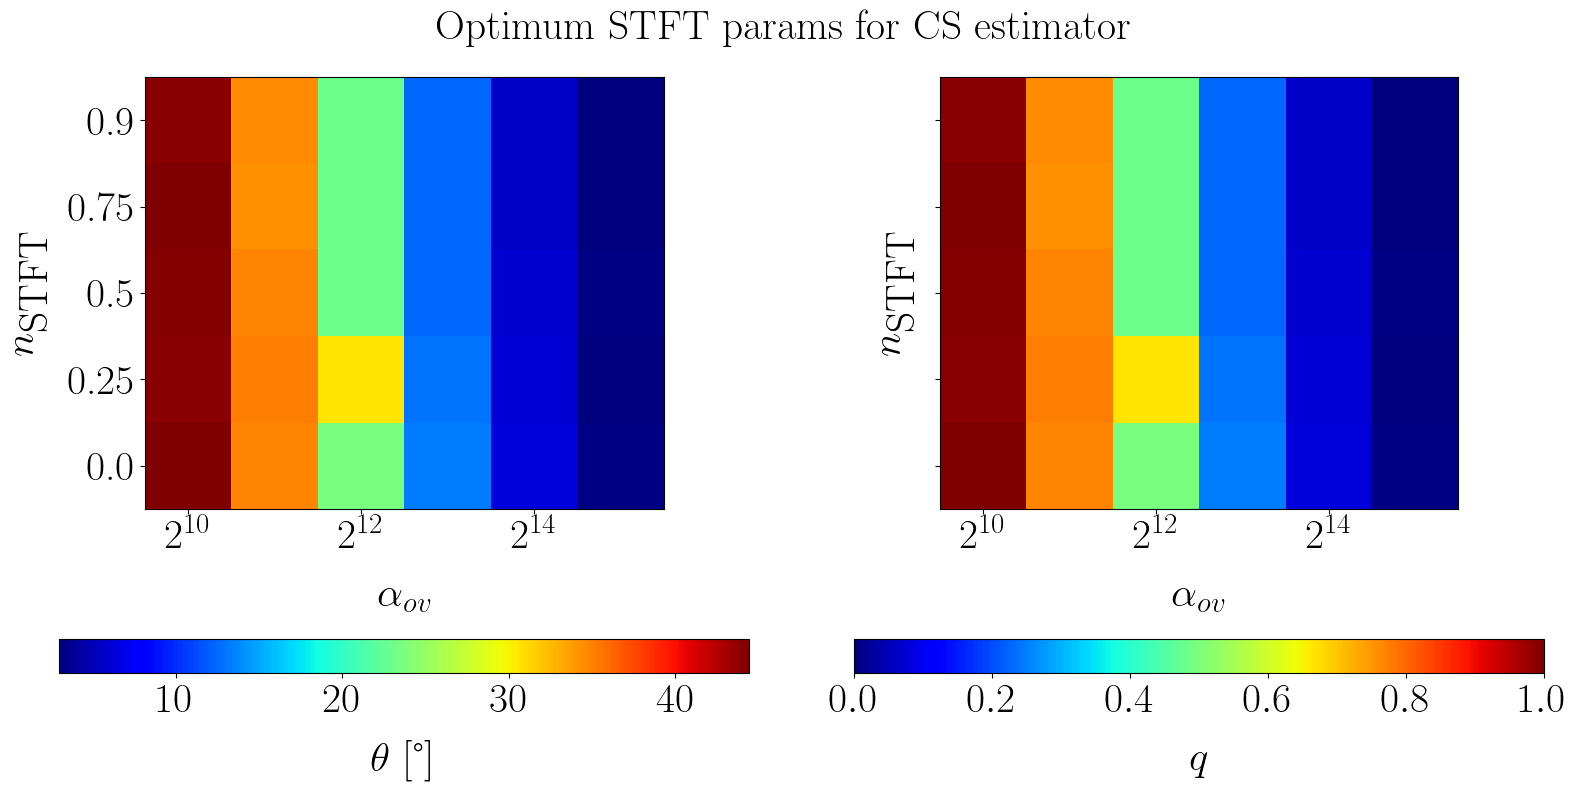

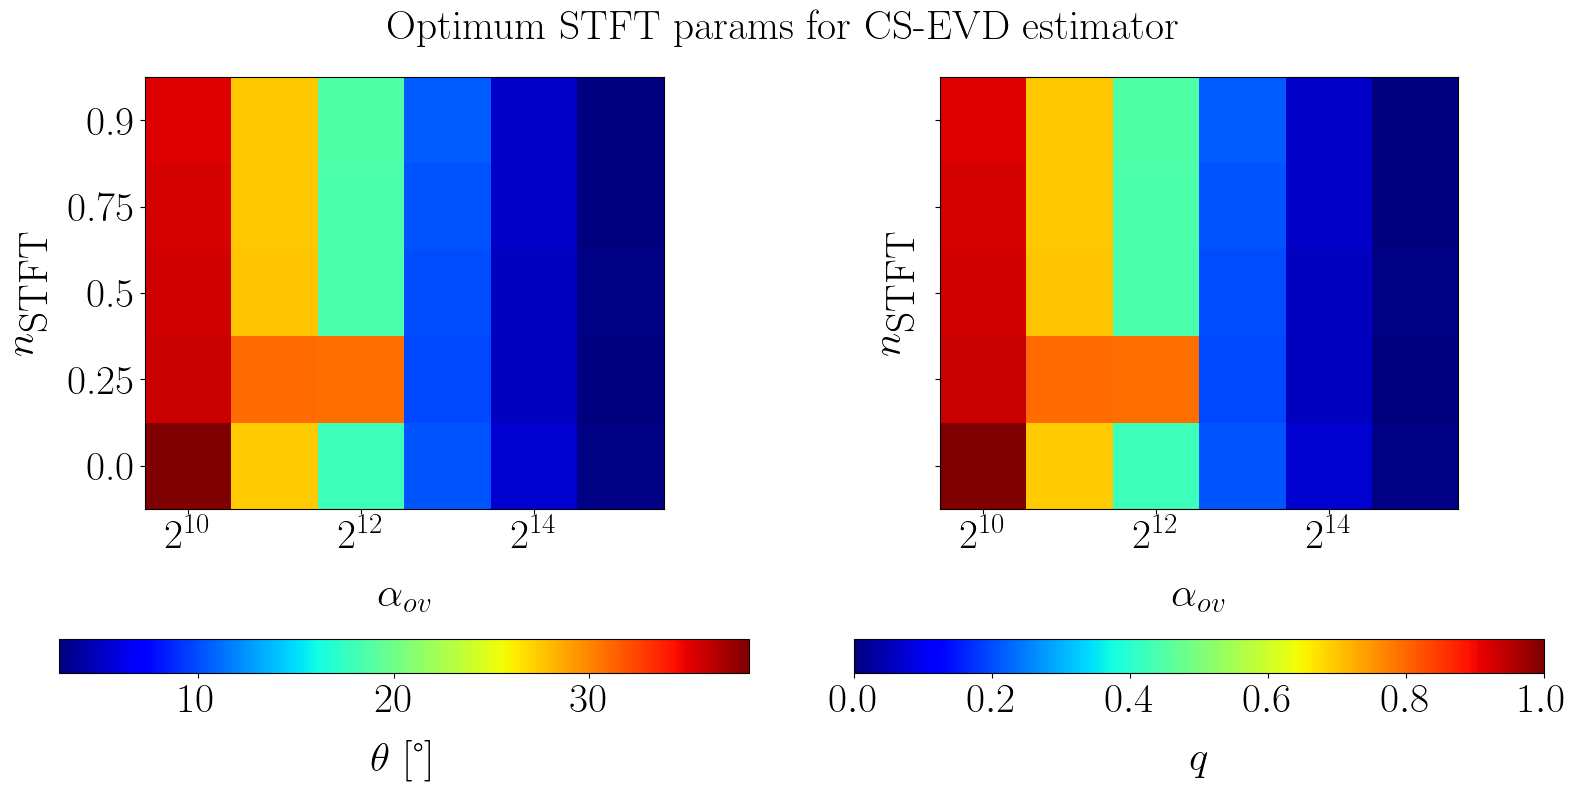

In [8]:
# Plot results
alpha_ovv, n_pow2_pp = np.meshgrid(ov_factors, n_stft_pow2)
if plot_minimisation_results:

    for rtf_e in rtf_estimators:
        theta_surf_mean = theta_mean_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_mean = normalize_metric_contrast(theta_surf_mean)
        q_mean_dB = 10 * np.log10(q_mean + 1e-5)

        theta_surf_med = theta_med_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_med = normalize_metric_contrast(theta_surf_med)

        theta_surf_sum = theta_sum_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_sum = normalize_metric_contrast(theta_surf_sum)

        fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True)

        ax = axs[0]
        im = ax.imshow(theta_surf_med.T, cmap="jet", origin="lower")
        ax.set_yticks(np.arange(len(ov_factors)))
        ax.set_yticklabels(ov_factors)
        ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
        ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

        # ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
        ax.set_xlabel(r"$\alpha_{ov}$")
        ax.set_ylabel(r"$n_{\textrm{STFT}}$")
        plt.colorbar(ax=ax, mappable=im, label=r"$\theta$ [°]", orientation="horizontal")

        ax = axs[1]
        im = ax.imshow(q_med.T, cmap="jet", vmin=0, vmax=1, origin="lower")
        ax.set_yticks(np.arange(len(ov_factors)))
        ax.set_yticklabels(ov_factors)
        ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
        ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

        # ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
        ax.set_xlabel(r"$\alpha_{ov}$")
        ax.set_ylabel(r"$n_{\textrm{STFT}}$")
        plt.colorbar(ax=ax, mappable=im, label=r"$q$", orientation="horizontal")
        fig.suptitle(f"Optimum STFT params for {rtf_e.upper()} estimator")

        # Save

        fpath = os.path.join(
            stft_twmin_params_folder, f"{rtf_e}_mean_theta_and_q_over_all_positions.png"
        )
        plt.savefig(fpath)

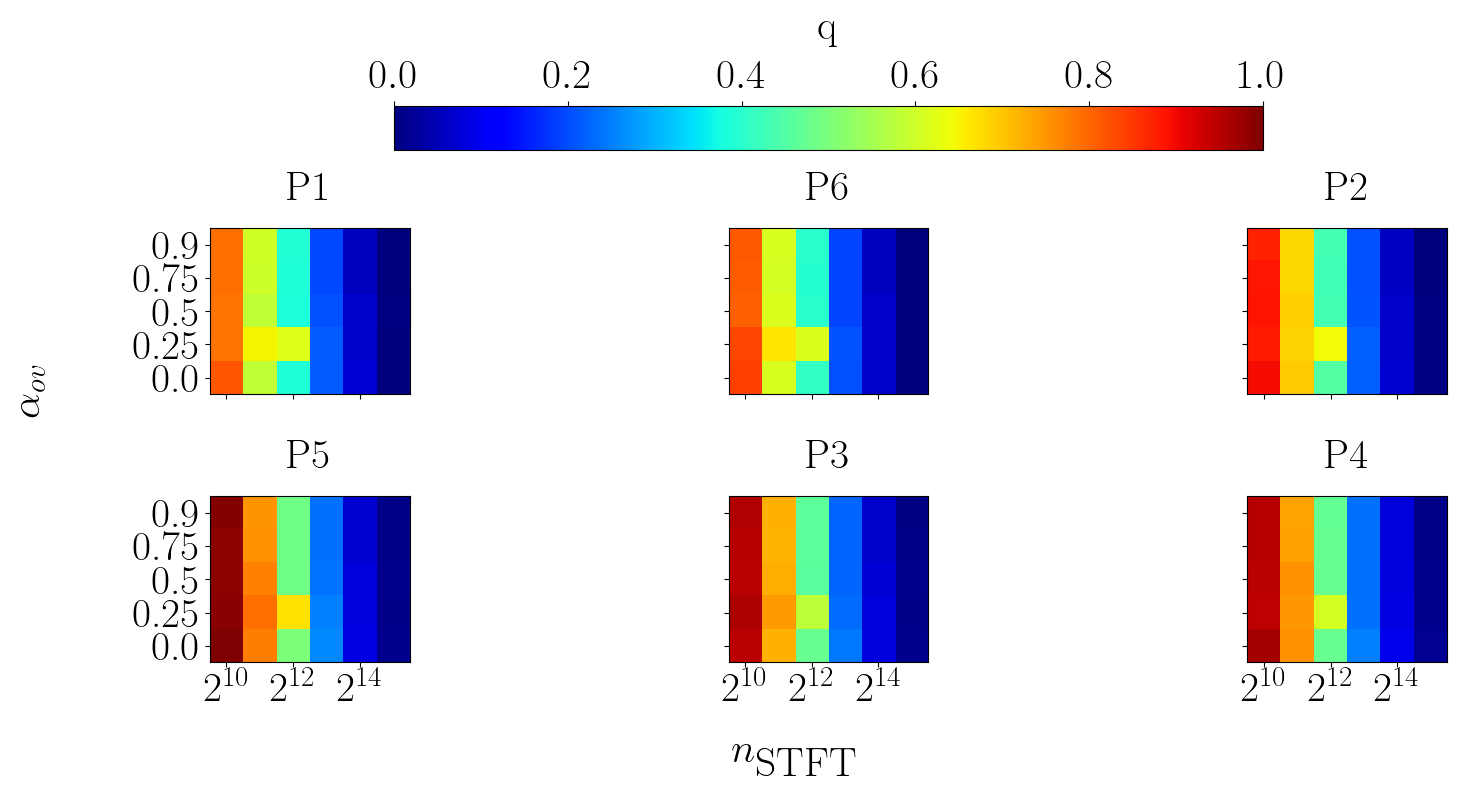

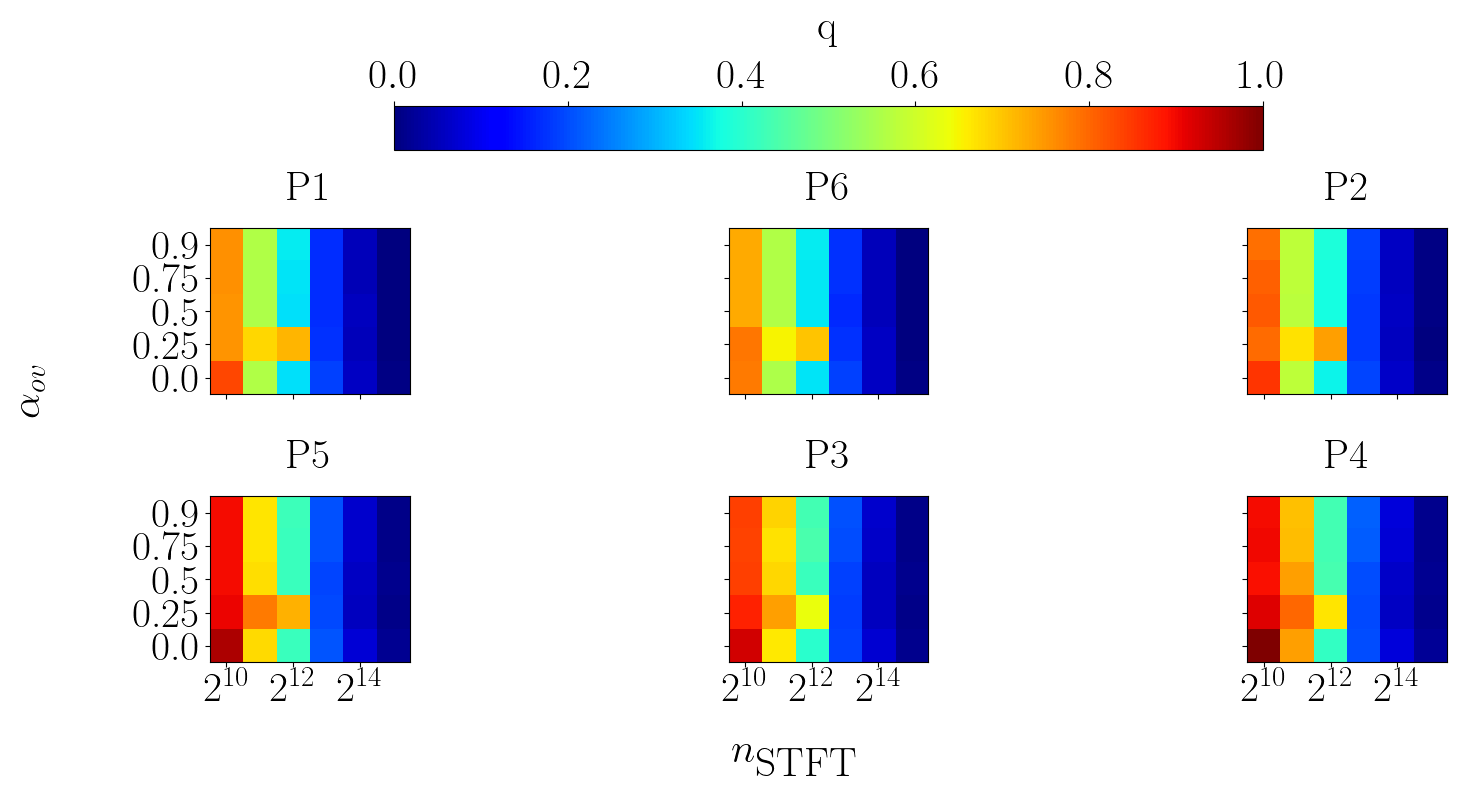

In [9]:
# Plot for each position
if plot_minimisation_results:
    for rtf_e in rtf_estimators:
        q_all_pos = normalize_metric_contrast(theta_all_pos[rtf_e])
        fig, axs = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=True)

        for ipos, pos in enumerate(src_label_sorted):
            ax = axs[ipos // 3, ipos % 3]
            q_pos = q_all_pos[ipos, :].reshape(n_pow2_pp.shape)

            im = ax.imshow(q_pos.T, cmap="jet", vmin=0, vmax=1, origin="lower")
            ax.set_yticks(np.arange(len(ov_factors)))
            ax.set_yticklabels(ov_factors)
            ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
            ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])
            ax.set_title(pos)

        fig.colorbar(
            im, ax=axs, orientation="horizontal", fraction=0.1, location="top", label="q"
        )
        fig.supylabel(r"$\alpha_{ov}$")
        fig.supxlabel(r"$n_{\textrm{STFT}}$")

        # Save
        fpath = os.path.join(stft_twmin_params_folder, f"{rtf_e}_q_each_position.png")
        plt.savefig(fpath)

## Définition des paramètres optimaux à utiliser pour la suite 

In [10]:
# Save optimum properties 
opti_stft_props = {
    "n_stft": {
        "cs": 2**15,
        "cs-evd": 2**15,
    },
    "alpha_ov": {
        "cs": 0.75,
        "cs-evd": 0.75,
    },
}

# Etape 3 : Calcul des grandeurs d'intérêt pour différentes tailles de signal Tw

In [11]:

if run_sliced_rtf_computation:
    results = {rtf_e: {recording_name: [] for recording_name in static_records} for rtf_e in rtf_estimators}
    
    # Progress bar 
    index = 0
    n_iter = len(rtf_estimators) * len(static_records)
    prev_progress = 0

    fs_sweep.records_folder = root_tmp
    for rtf_e in rtf_estimators:
        # print("--------------------------------")
        # print(f"{rtf_e.upper()} estimator")

        # Update fiberscope manager with optimum params
        fsm.nperseg = opti_stft_props["n_stft"][rtf_e]
        fsm.noverlap = fsm.nperseg * opti_stft_props["alpha_ov"][rtf_e]

        # Update cov and rtf managers with new stft params
        fsm.set_managers(fs=fs, idx_rcv_ref=idx_rcv_ref)

        # Iterate over static files
        for recording_name in static_records:

            # print(f"\t {recording_name}")
            prev_progress = progression_bar(index=index, index0=0, indexf=n_iter, prev_progress=prev_progress)
            index += 1
            
            # Compute reference RTF by deconvolution
            xr_data = fsm.derive_feature(
                recording_name=recording_name,
                records_folder=fs_sweep.records_folder,
                signal=fs_sweep,
                save=False,
                rtf_estimator=rtf_e
            )

            # Drop rtf_amp_hat and rtf_phase_hat to ensure that they are recomputed for each slice
            xr_data = xr_data.drop_vars(
                ["rtf_amp_hat", "rtf_phase_hat", "f_csdm", "Rx", "Rv"]
            )  

            # Iterate over slices
            i_slice = 0
            for Tw_i in Tw:
                # print(f"\t\t Window : t c [0, {Tw_i}]s")

                # Slice the required duration
                xr_data_slice = xr_data.copy()
                xr_data_slice = xr_data_slice.sel(
                    time=slice(0, Tw_i)
                )  # From 0 to Tw_i 

                # Compute rtf for current slice
                xr_data_slice = fsm.get_rtf(
                    xr_data=xr_data_slice, Rv_global=None, rtf_estimator=rtf_e
                )

                # Drop useless variables
                xr_data_slice = xr_data_slice.drop_vars(
                    [
                        "signal",
                        "stft_amp",
                        "stft_phase",
                        "ri_hat",
                        "tf_hat_amp",
                        "tf_hat_phase",
                    ]
                )

                # Store results
                results[rtf_e][recording_name].append(xr_data_slice)

    # Convert results to datasets and save
    for rtf_e in rtf_estimators:
        for recording_name in static_records:
            for i in range(len(Tw)):
                results[rtf_e][recording_name][i].to_netcdf(
                    os.path.join(
                        sliced_data_folder,
                        f"rtf_sliced_static_{recording_name}_Tw{int(Tw[i])}_{rtf_e}.nc"
                    )
                )

else:
    # Load pre-computed datasets
    results = {rtf_e: {recording_name: [] for recording_name in static_records} for rtf_e in rtf_estimators}
    for rtf_e in rtf_estimators:
        for recording_name in static_records:
            for i in range(len(Tw)):
                xr_slice = xr.open_dataset(
                    os.path.join(
                        sliced_data_folder,
                        f"rtf_sliced_static_{recording_name}_Tw{int(Tw[i])}_{rtf_e}.nc"
                    )
                )
                results[rtf_e][recording_name].append(xr_slice)



# Étape 4 : Analyse des variations 

## Vecteurs de RTF 

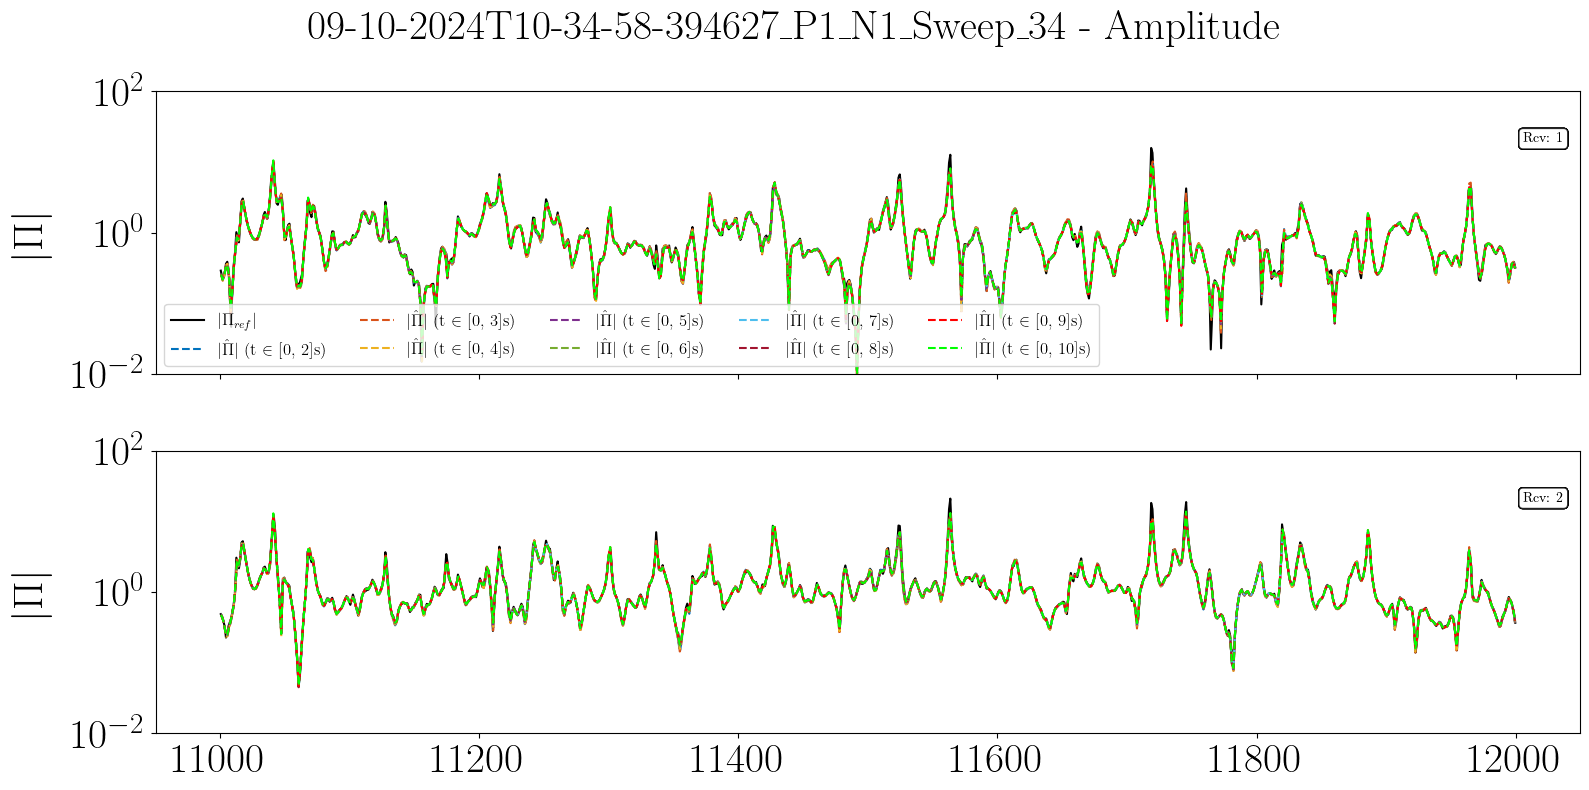

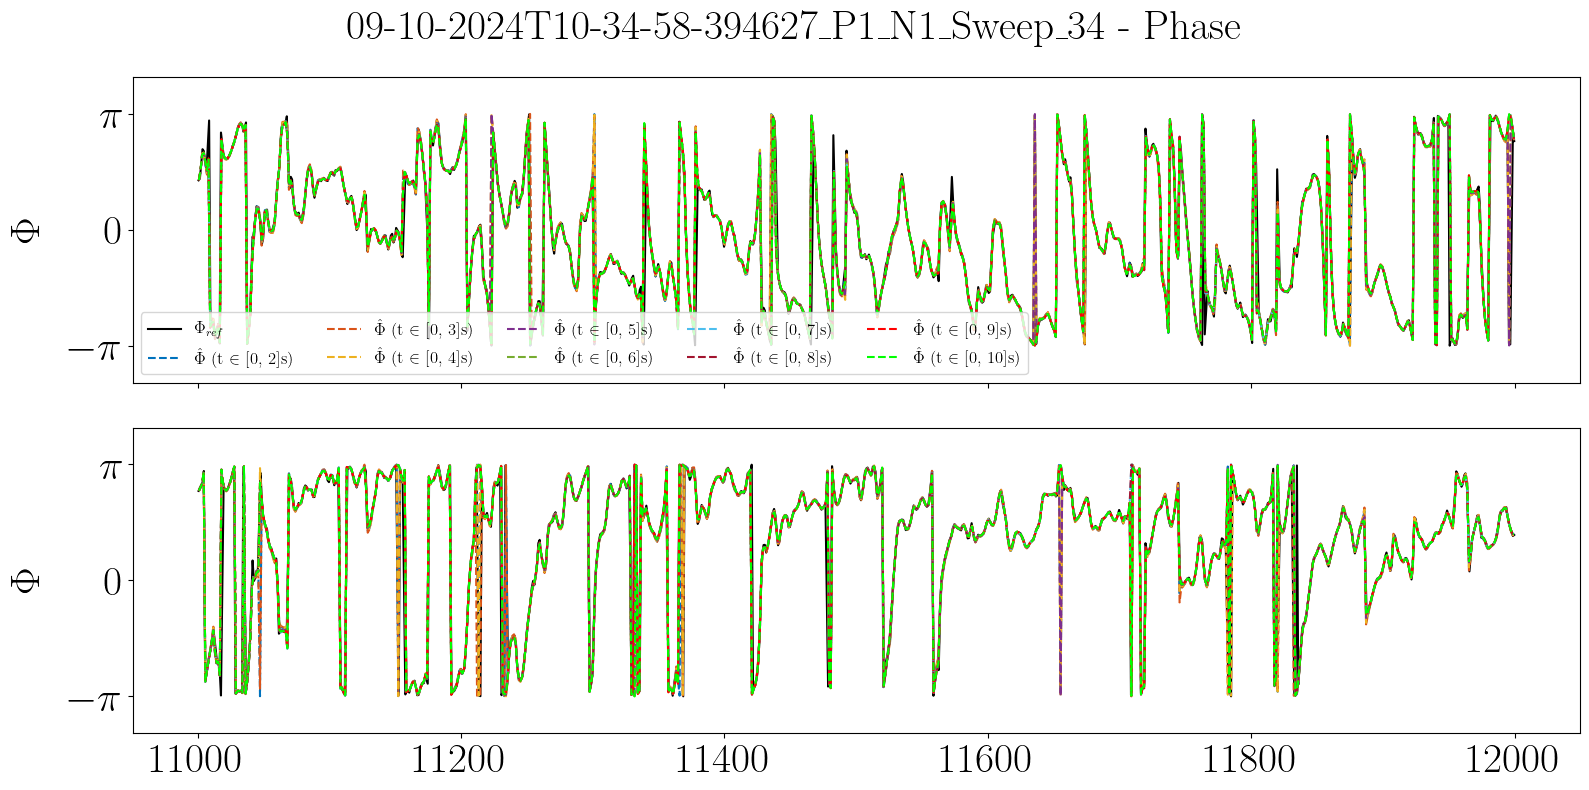

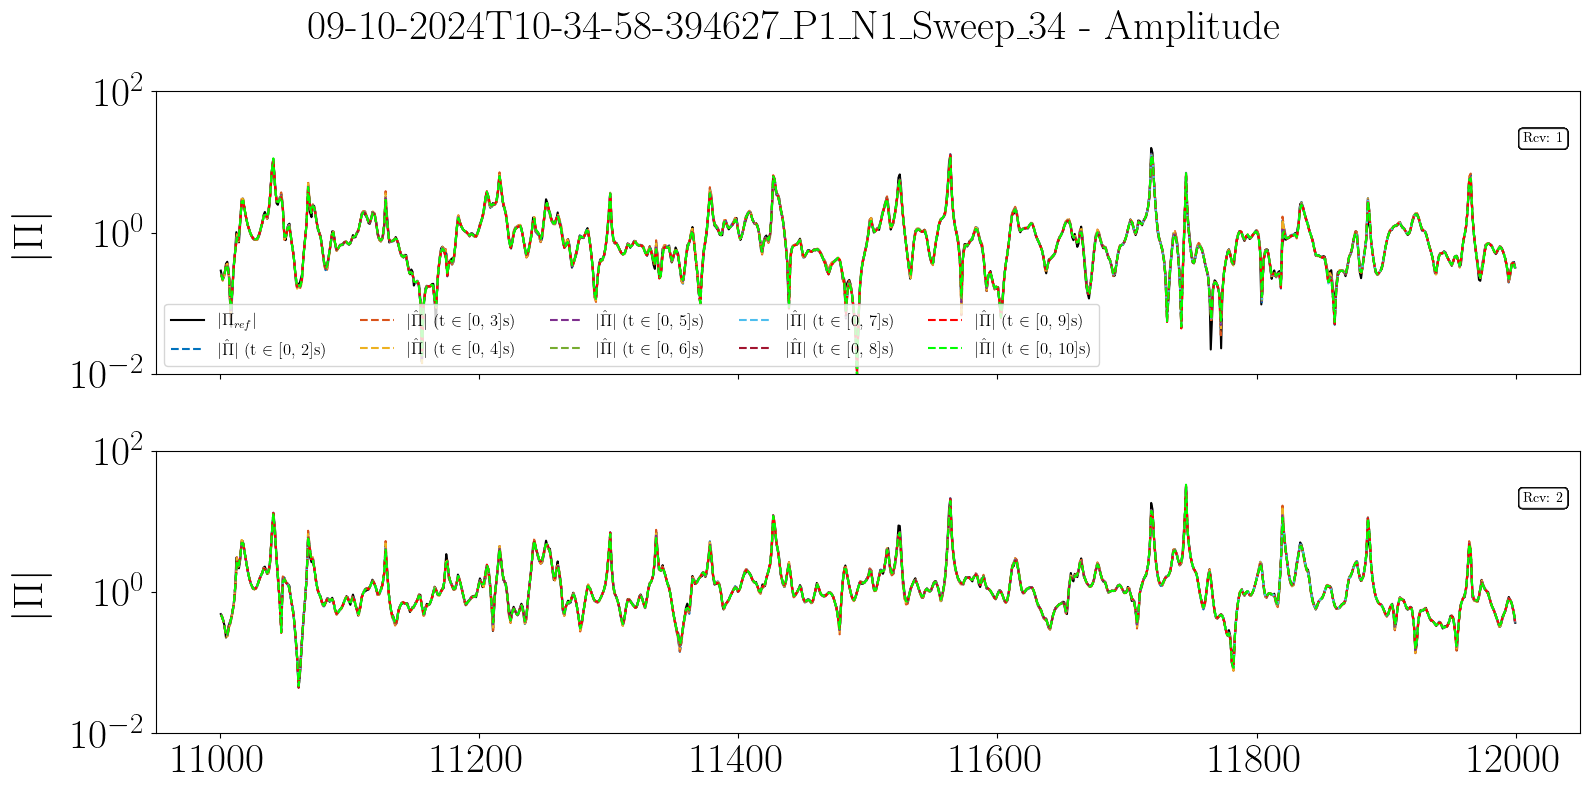

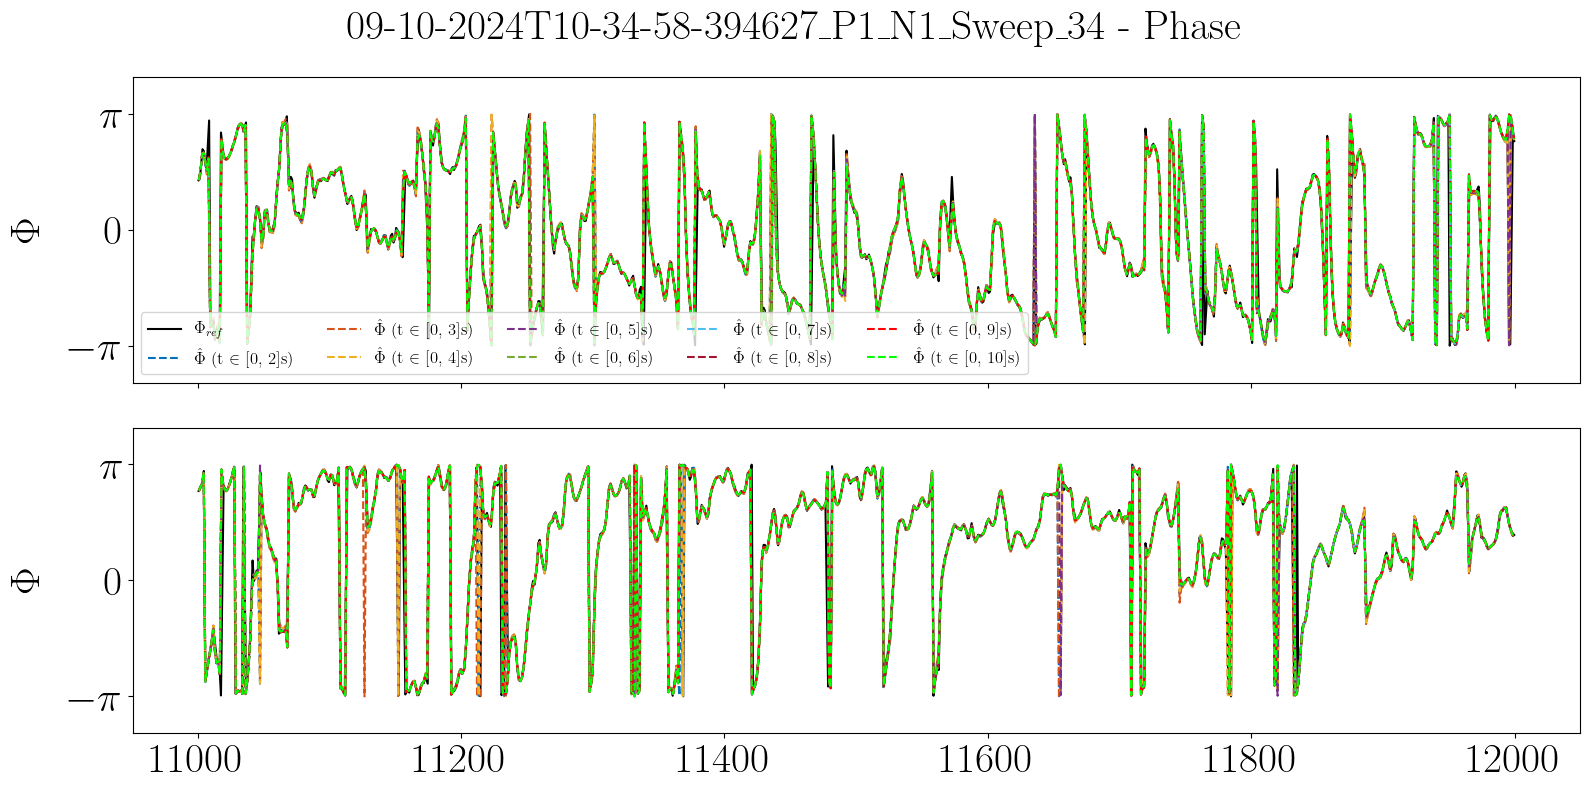

In [12]:
# Plot results
n_win = len(Tw) 

# Select a band to plot the estimated rtfs
fmin = 11000
fmax = 12000

if plot_tw_slice_rtf_results:
    for rtf_e in rtf_estimators:

        # Iterate over recordings
        show_plot = True
        for recording_name in static_records:
            # Iterate over slices

            for i_slice in range(n_win):
                ds_rtf = results[rtf_e][recording_name][i_slice]

                if i_slice == 0:
                    # nl = ds_rtf.sizes["h_index"]
                    nl = 2  # Plot only first 2 receivers

                    # RTF Amplitude
                    fig_amp, axs_amp = plt.subplots(nl, 1, sharex=True)
                    fig_amp.suptitle(f"{recording_name} - Amplitude")
                    # RTF Phase
                    fig_phase, axs_phase = plt.subplots(nl, 1, sharex=True)
                    fig_phase.suptitle(f"{recording_name} - Phase")

                # Plot rtf for each receiver
                for i in range(nl):
                    # Select receiver
                    ds_rtf_rcv = ds_rtf.isel(h_index=i)
                    # Select frequency band
                    ds_rtf_rcv = ds_rtf_rcv.sel(f_ir=slice(fmin, fmax))
                    ds_rtf_rcv = ds_rtf_rcv.sel(f_rtf=slice(fmin, fmax))

                    # Extract RTF ref (from deconvolution)
                    rtf_ref_mod = ds_rtf_rcv.rtf_amp
                    rtf_ref_phase = ds_rtf_rcv.rtf_phase
                    # Extract RTF hat (from CS-EVD)
                    rtf_hat_mod = ds_rtf_rcv.rtf_amp_hat
                    rtf_hat_phase = ds_rtf_rcv.rtf_phase_hat

                    # Interp RTF ref at RTF hat frequencies (nearest neigbor)
                    rtf_ref_mod = rtf_ref_mod.sel(
                        f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
                    )
                    rtf_ref_phase = rtf_ref_phase.sel(
                        f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
                    )

                    # Plot RTF mod
                    if i_slice == 0:
                        rtf_ref_mod.plot(label=r"$|\Pi_{ref}|$", color="k", ax=axs_amp[i])

                    rtf_hat_mod.plot(
                        label=r"$|\hat{\Pi}|$" + rf" (t $\in$ [0, {Tw[i_slice]}]s)",
                        color=color(i_slice),
                        linestyle="--",
                        ax=axs_amp[i],
                    )
                    axs_amp[i].set_ylim([0.01, 100])
                    axs_amp[i].set_yscale("log")
                    axs_amp[i].set_xlabel("")
                    axs_amp[i].set_ylabel(r"$|\Pi|$")
                    axs_amp[i].set_title("")
                    # axs_amp[i].set_title(f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}")

                    if i == 0:
                        axs_amp[i].legend(
                            fontsize=12, ncols=(n_win + 1) // 2 + (n_win + 1) % 2, loc="lower left",
                        )

                    # Add annotation for receiver index and record name
                    axs_amp[i].annotate(
                        f"Rcv: {ds_rtf_rcv.h_index.values}",
                        xy=(0.96, 0.82),
                        xycoords="axes fraction",
                        fontsize=10,
                        color="black",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    )

                    # Plot phase
                    if i_slice == 0:
                        rtf_ref_phase.plot(label=r"$\Phi_{ref}$", color="k", ax=axs_phase[i])

                    rtf_hat_phase.plot(
                        label=r"$\hat{\Phi}$" + rf" (t $\in$ [0, {Tw[i_slice]}]s)",
                        color=color(i_slice),
                        linestyle="--",
                        ax=axs_phase[i],
                    )
                    axs_phase[i].set_xlabel("")
                    axs_phase[i].set_ylabel(r"$\Phi$")
                    axs_phase[i].set_title("")
                    axs_phase[i].set_ylim(-np.pi - 1, np.pi + 1)
                    # Set yticks annotated in multiples of pi
                    axs_phase[i].set_yticks([-np.pi, 0, np.pi])
                    axs_phase[i].set_yticklabels(
                        [r"$-\pi$", "0", r"$\pi$"]
                    )
                    # axs_phase[i].set_title(
                    #     f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}"
                    # )

                    if i == 0:
                        axs_phase[i].legend(
                            fontsize=12,
                            ncols=(n_win + 1) // 2 + (n_win + 1) % 2,
                            loc="lower left",
                        )

            # Save
            pos_id = recording_name.split("_")[1]
            fig_amp.savefig(os.path.join(rtf_subfolders[rtf_e][recording_name], f"{pos_id}_rtf_amp_vs_Tslice.png"), dpi=300, bbox_inches="tight",)
            fig_phase.savefig(
                os.path.join(
                    rtf_subfolders[rtf_e][recording_name],
                    f"{pos_id}_rtf_phase_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            if show_plot:
                plt.show()
                show_plot = False
            
            plt.close("all")

## Matrices de covariance 

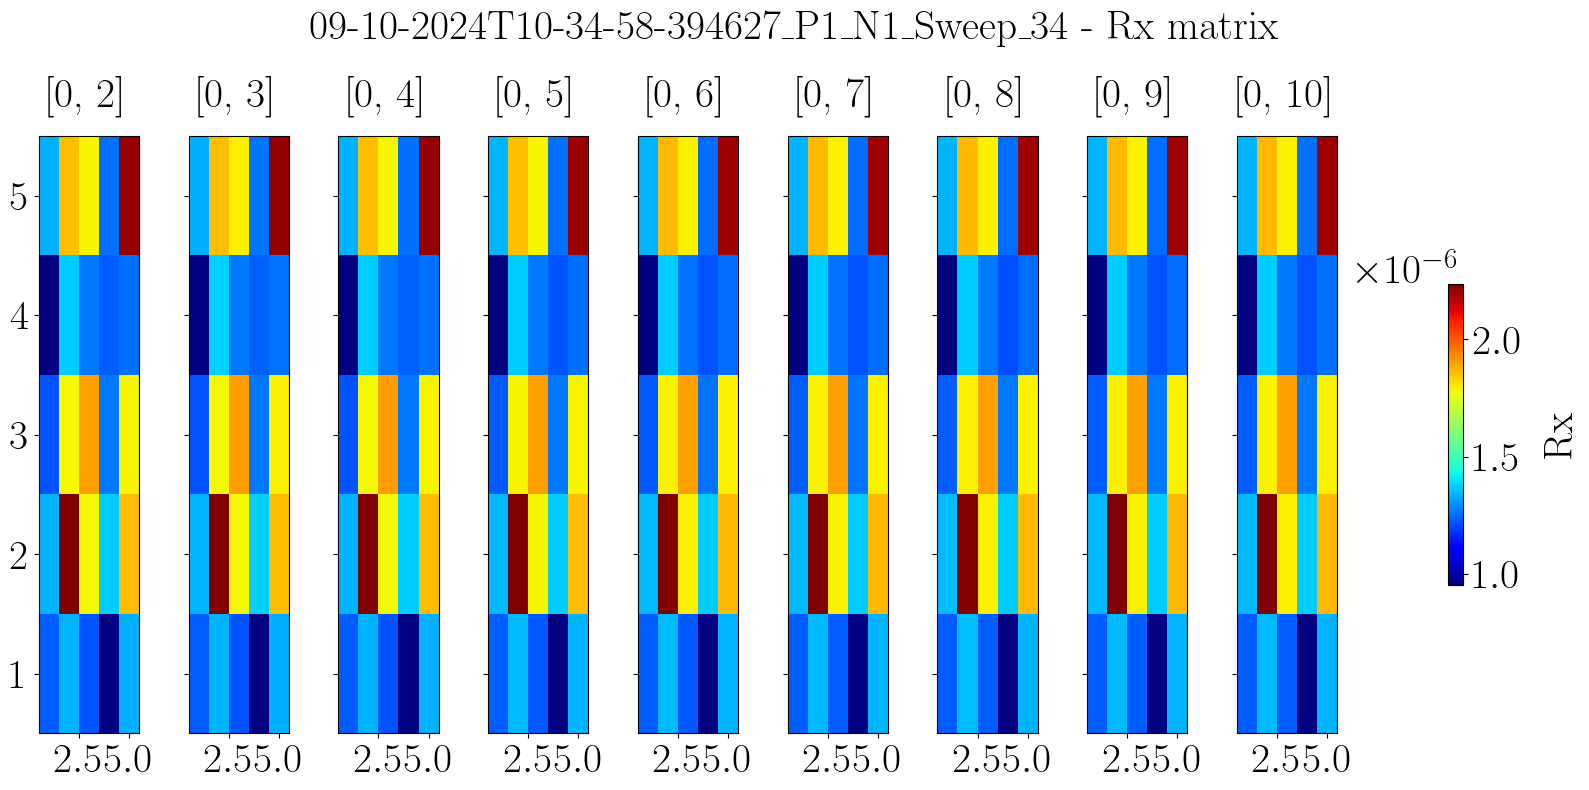

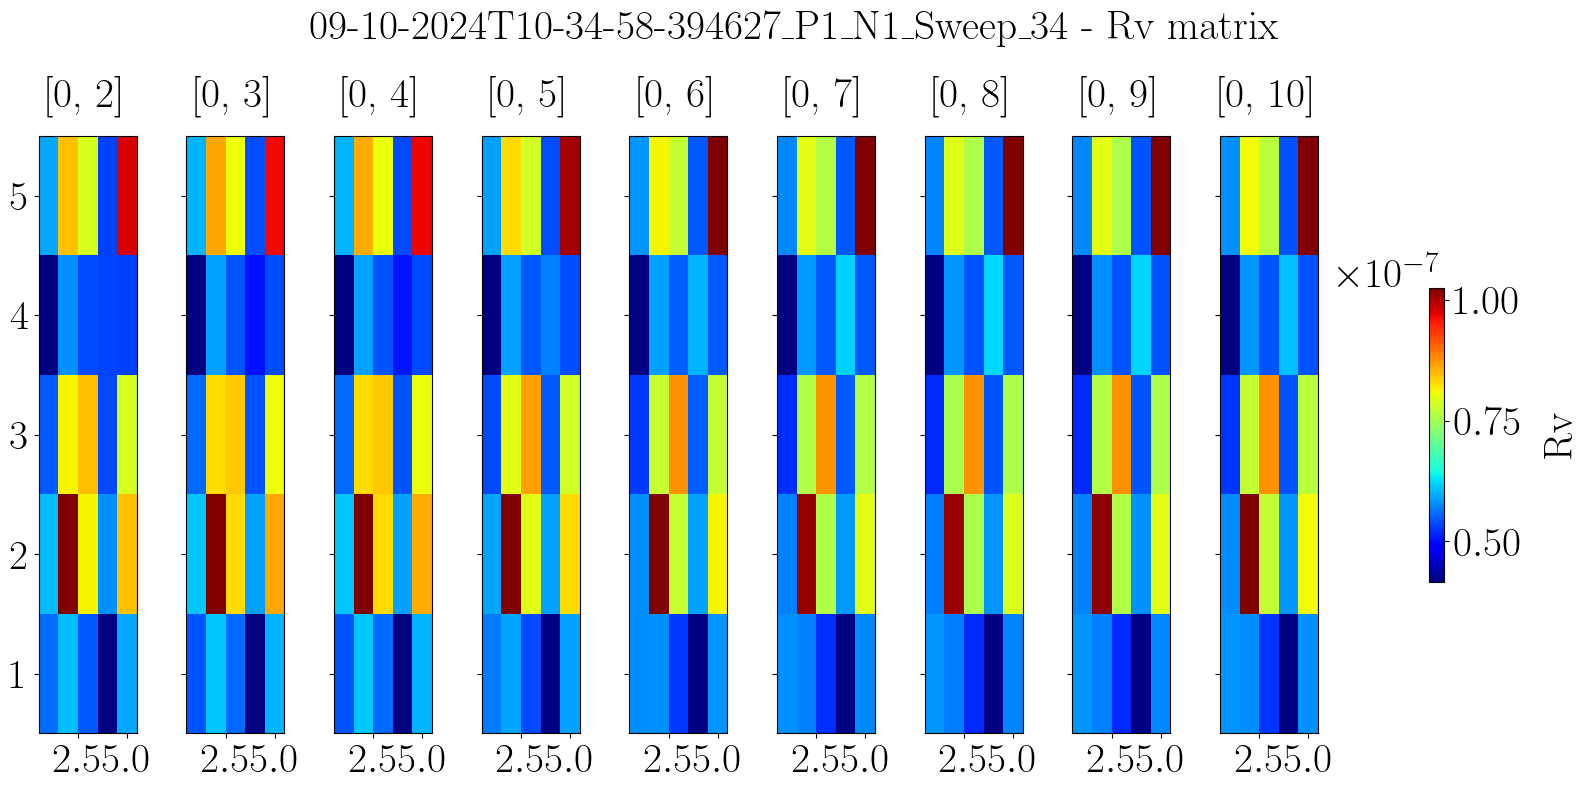

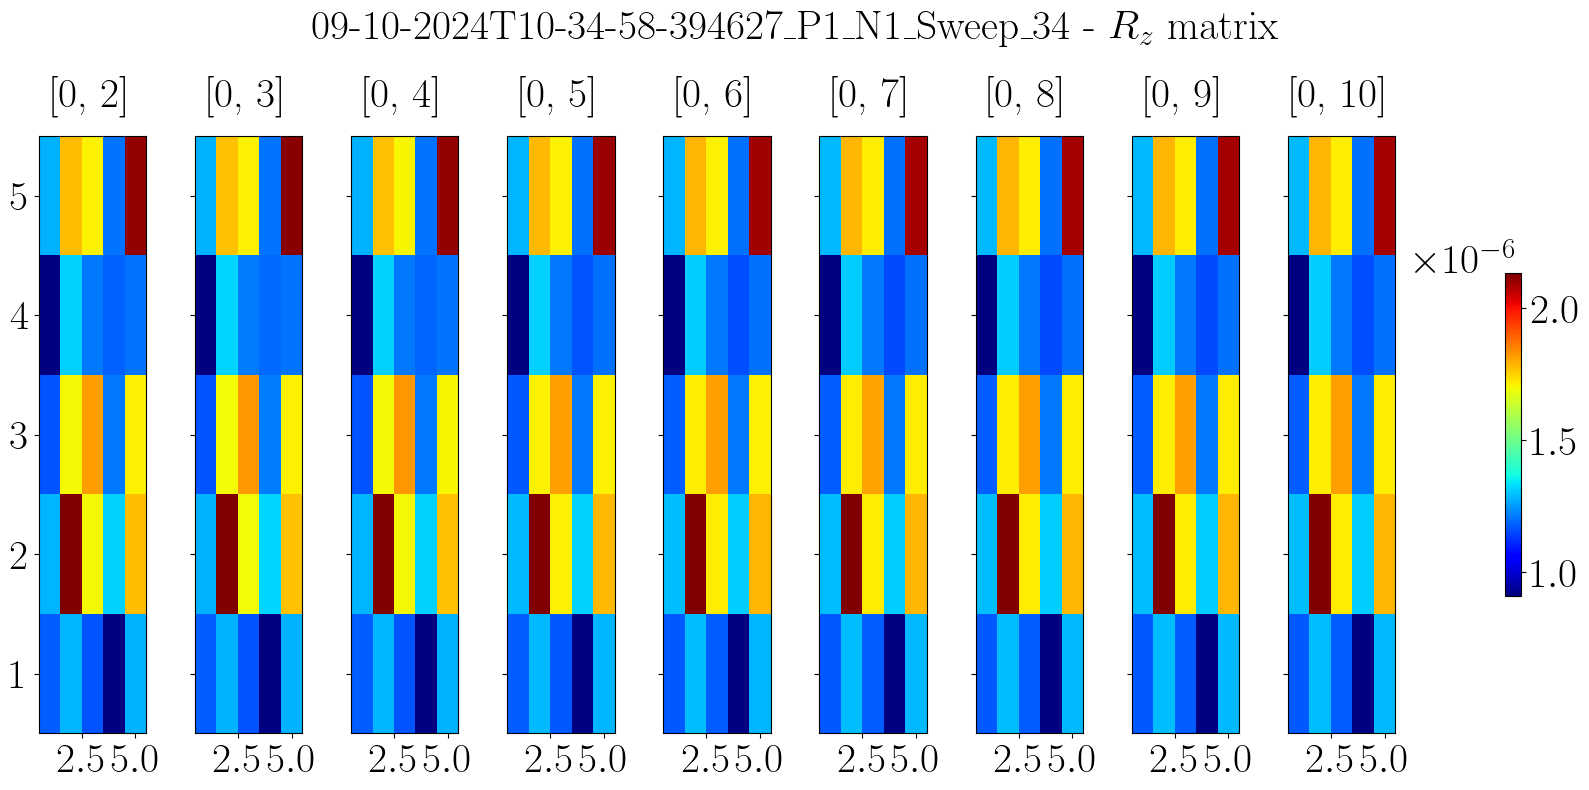

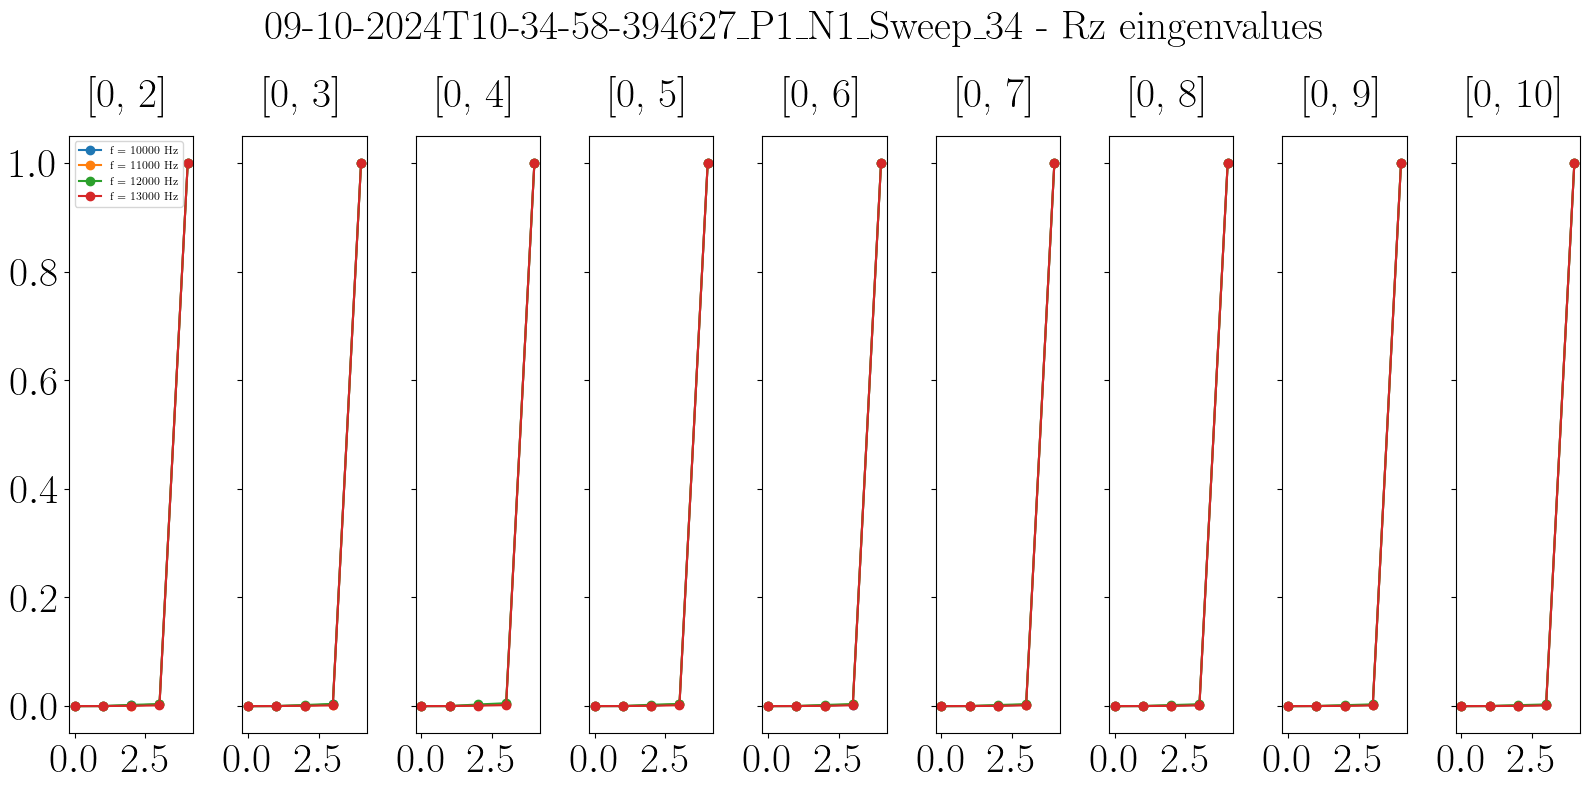

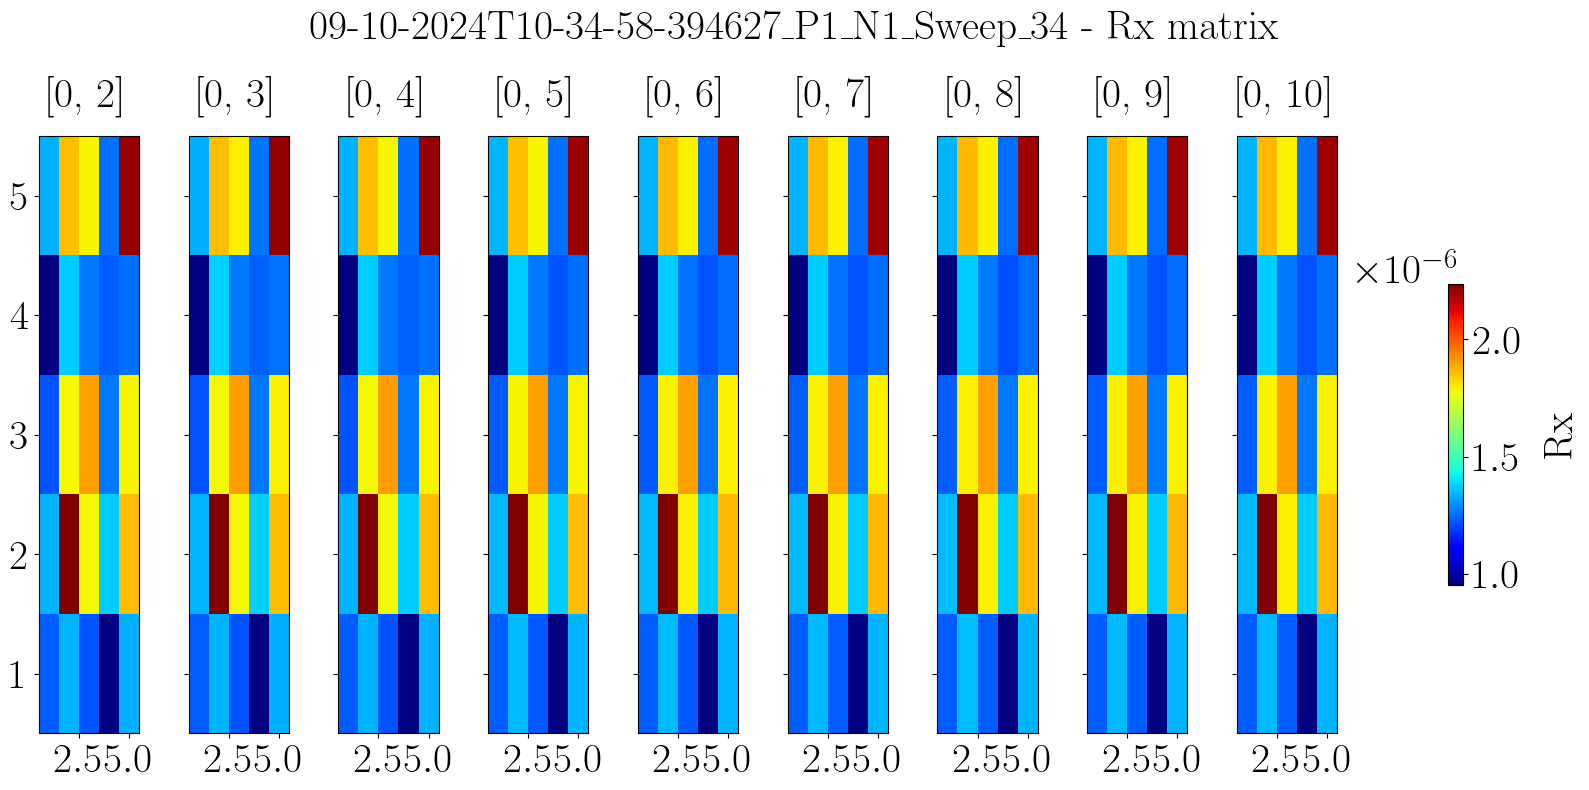

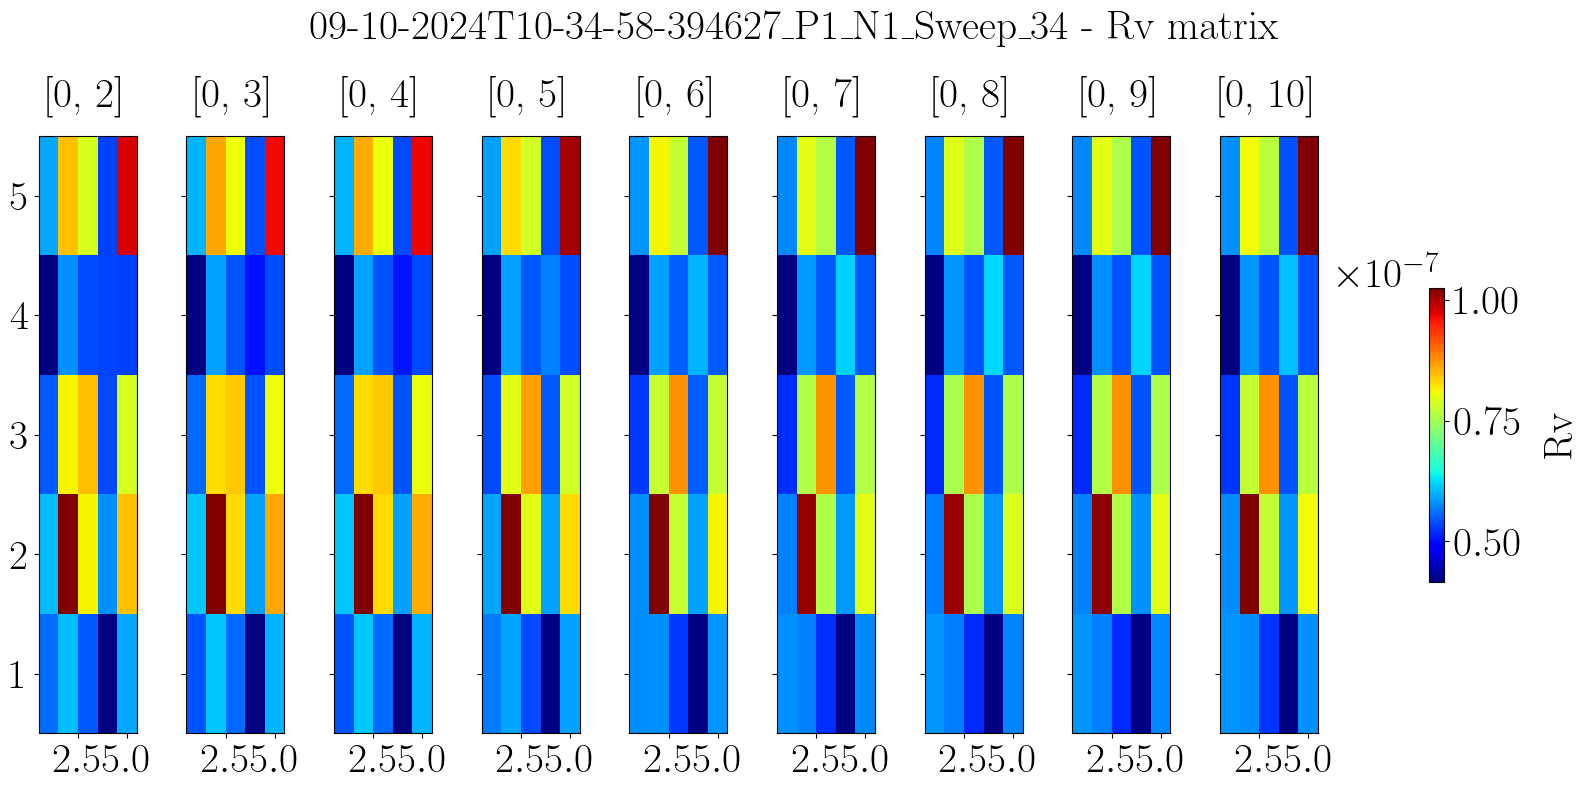

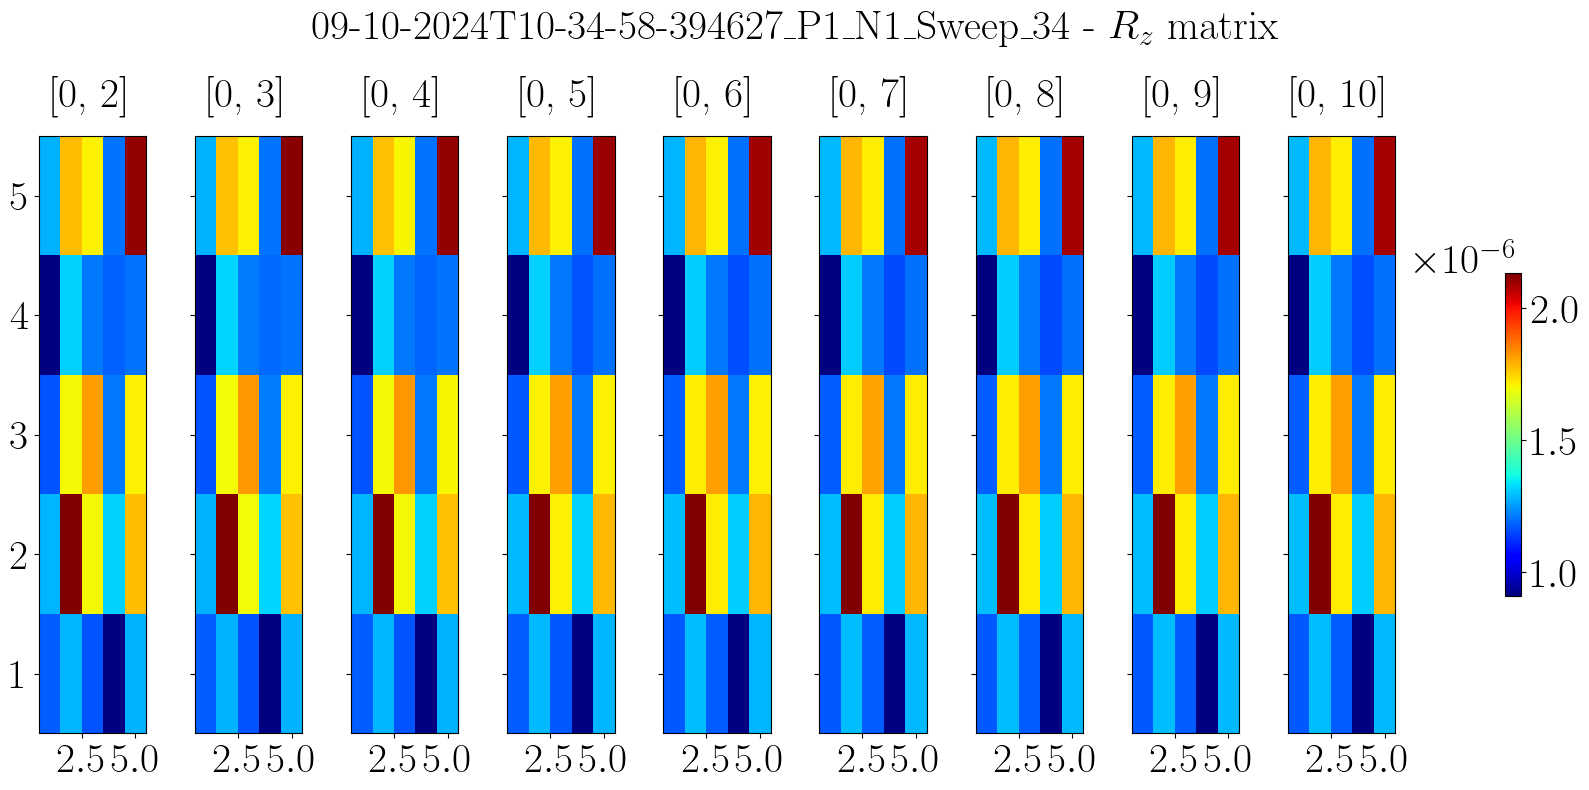

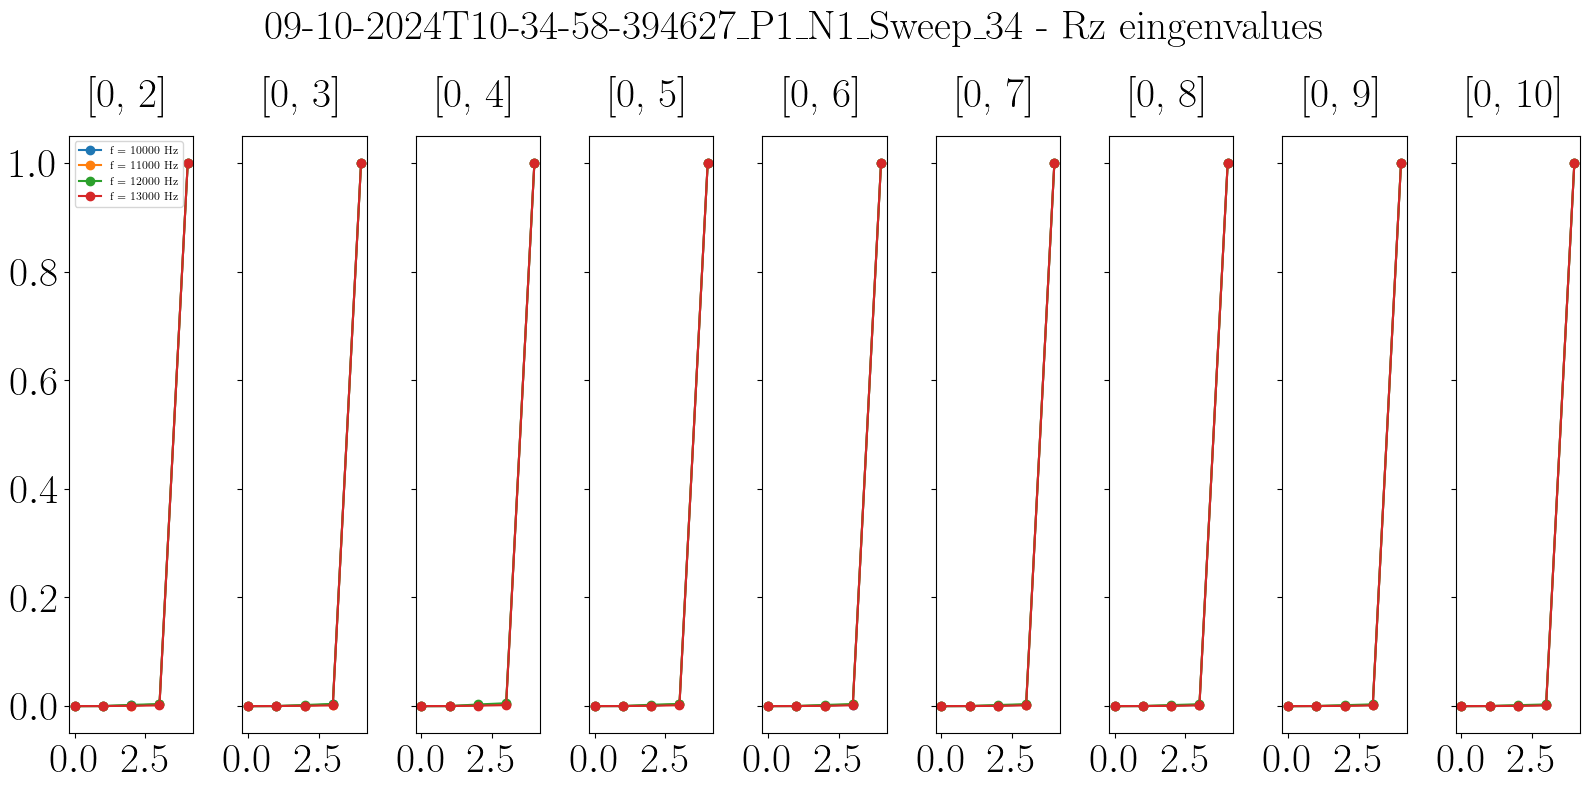

In [19]:
# Plot results
n_win = len(Tw)

# Select a band to plot the estimated rtfs
fmin = 11000
fmax = 12000

if plot_tw_slice_rtf_results:
    for rtf_e in rtf_estimators:

        # Iterate over recordings
        show_plot = True
        for recording_name in static_records:
            # Iterate over slices

            for i_slice in range(n_win):
                ds_rtf = results[rtf_e][recording_name][i_slice]

                if i_slice == 0:
                    # nl = ds_rtf.sizes["h_index"]
                    nl = 2  # Plot only first 2 receivers

                    # Rx matrix
                    fig_rx, axs_rx = plt.subplots(1, n_win, sharey=True)
                    fig_rx.suptitle(f"{recording_name} - Rx matrix")
                    # Rv matrix
                    fig_rv, axs_rv = plt.subplots(1, n_win, sharey=True)
                    fig_rv.suptitle(f"{recording_name} - Rv matrix")
                    # Rz matrix
                    fig_rz, axs_rz = plt.subplots(1, n_win, sharey=True)
                    fig_rz.suptitle(rf"{recording_name} - $R_z$ matrix")
                    # Eingenvalue Rz matrix
                    fig_rz_ev, axs_rz_ev = plt.subplots(
                        1, n_win, sharey=True, constrained_layout=True
                    )
                    fig_rz_ev.suptitle(f"{recording_name} - Rz eingenvalues")

                # f_csdm = fmin
                f_csdm = slice(fmin, fmax)
                add_colorbar = i_slice == n_win - 1  # Add colorbar only for last subplot
                cbar_kwargs = dict(label=r"% error") if add_colorbar else None
                dr_vmin = -100
                dr_vmax = 100

                r_title = f"[0, {Tw[i_slice]}]"
                # Plot Rx
                # rx = ds_rtf.sel(f_csdm=f_csdm, method="nearest").Rx     # Only one freq to plot
                rx = ds_rtf.sel(f_csdm=f_csdm).Rx.mean(
                    dim="f_csdm"
                )  # Mean over frequency slice
                rx.plot(ax=axs_rx[i_slice], cmap="jet", add_colorbar=add_colorbar)
                axs_rx[i_slice].set_xlabel("")
                axs_rx[i_slice].set_ylabel("")
                axs_rx[i_slice].set_title(r_title)

                # Plot Rv
                # rv = ds_rtf.sel(f_csdm=f_csdm, method="nearest").Rv     # Only one freq to plot
                rv = ds_rtf.sel(f_csdm=f_csdm).Rv.mean(
                    dim="f_csdm"
                )  # Mean over frequency slice
                rv.plot(
                    ax=axs_rv[i_slice],
                    # label=f"T = {t_min_slice + (i_slice+1) * time_step}s",
                    cmap="jet",
                    add_colorbar=add_colorbar,
                )
                axs_rv[i_slice].set_xlabel("")
                axs_rv[i_slice].set_ylabel("")
                axs_rv[i_slice].set_title(r_title)

                # Plot Rz
                rz = rx - rv
                rz.plot(
                    ax=axs_rz[i_slice],
                    # label=f"T = {t_min_slice + (i_slice+1) * time_step}s",
                    cmap="jet",
                    add_colorbar=add_colorbar,
                )
                axs_rz[i_slice].set_xlabel("")
                axs_rz[i_slice].set_ylabel("")
                axs_rz[i_slice].set_title(r_title)

                # Plot Rz Eigenvalues
                f_target = 12000
                # f_t = [10000, 10500, 11000, 11500, 12000, 12500, 13000]
                f_t = [10000, 11000, 12000, 13000]
                rx_ = ds_rtf.Rx
                rv_ = ds_rtf.Rv

                for f_target in f_t:
                    rx_f = rx_.sel(f_csdm=f_target, method="nearest")
                    rv_f = rv_.sel(f_csdm=f_target, method="nearest")
                    # rank_xf = np.linalg.matrix_rank(rx_f)
                    # rank_vf = np.linalg.matrix_rank(rv_f)
                    # print(f"Rank Rx at f = {f_target}Hz : {rank_xf} (nl = {nl})")
                    # print(f"Rank Rv at f = {f_target}Hz : {rank_vf} (nl = {nl})")
                    eigval_x, eigve_x = eigh(
                        rx_f,
                        check_finite=False,
                    )
                    # print(
                    #     f"Rx eigenvalues at f = {f_target}Hz : {eigval_x / np.max(np.abs(eigval_x))}"
                    # )
                    eigval_v, eigve_v = eigh(
                        rv_f,
                        check_finite=False,
                    )
                    # print(
                    #     f"Rv eigenvalues at f = {f_target}Hz : {eigval_v / np.max(np.abs(eigval_v))}"
                    # )

                    rz_f = rx_f - rv_f
                    eigval, eigve = eigh(
                        rz_f,
                        check_finite=False,
                        # eigvals_only=True,
                        # subset_by_index=[nr - 1, nr - 1],  # Only get the major eigenvector
                    )
                    # import scipy
                    # Normalize eigval
                    eigval_norm = eigval / np.max(np.abs(eigval))

                    # print(f"Rz eigenvalues at f = {f_target}Hz : {eigval_norm}")
                    # rank_f = np.linalg.matrix_rank(rz_f, tol=np.max(eigval[:-1]) * 1.1)
                    # print(f"Rank of Rz at f = {f_target}Hz : {rank_f} (nl = {nl})")
                    # rank_d = np.linalg.matrix_rank(
                    #     np.diag(eigval_norm), tol=np.max(eigval_norm[:-1]) * 1.1
                    # )
                    # print(
                    #     f"Rank of diag(eigval) at f = {f_target}Hz : {rank_d} (nl = {nl})"
                    # )
                    axs_rz_ev[i_slice].plot(
                        eigval_norm, label=f"f = {f_target} Hz", marker="o"
                    )
                axs_rz_ev[i_slice].set_xlabel("")
                axs_rz_ev[i_slice].set_ylabel("")
                axs_rz_ev[0].legend(fontsize=8)
                axs_rz_ev[i_slice].set_title(r_title)

            # Save
            pos_id = recording_name.split("_")[1]
            fig_rx.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_Rx_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            fig_rv.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_Rv_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            fig_rz.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_Rz_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            fig_rz_ev.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_Rz_eigvals.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )

            if show_plot:
                plt.show()
                show_plot = False
                
            plt.close("all")

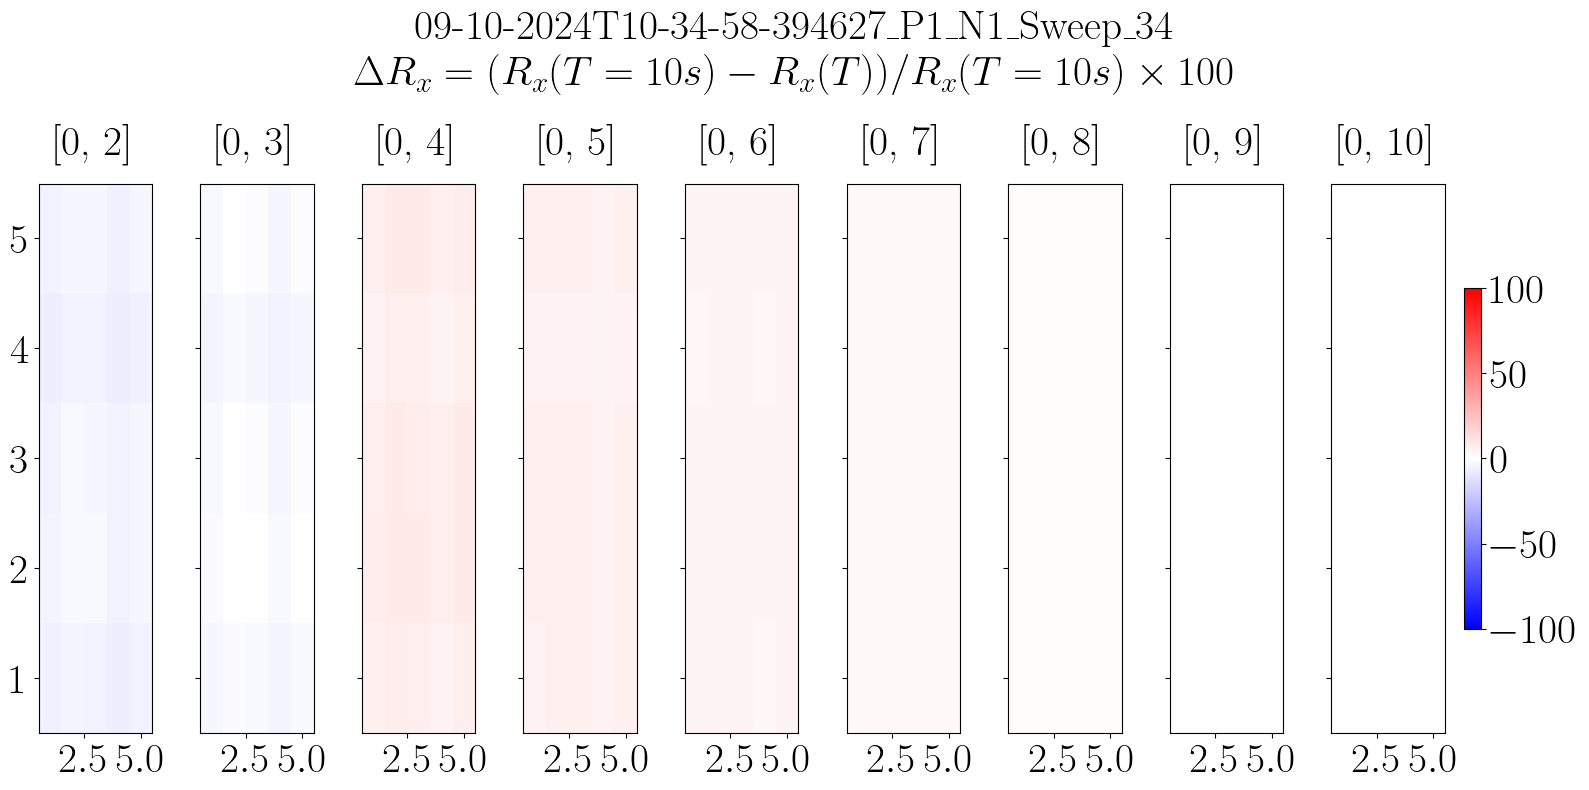

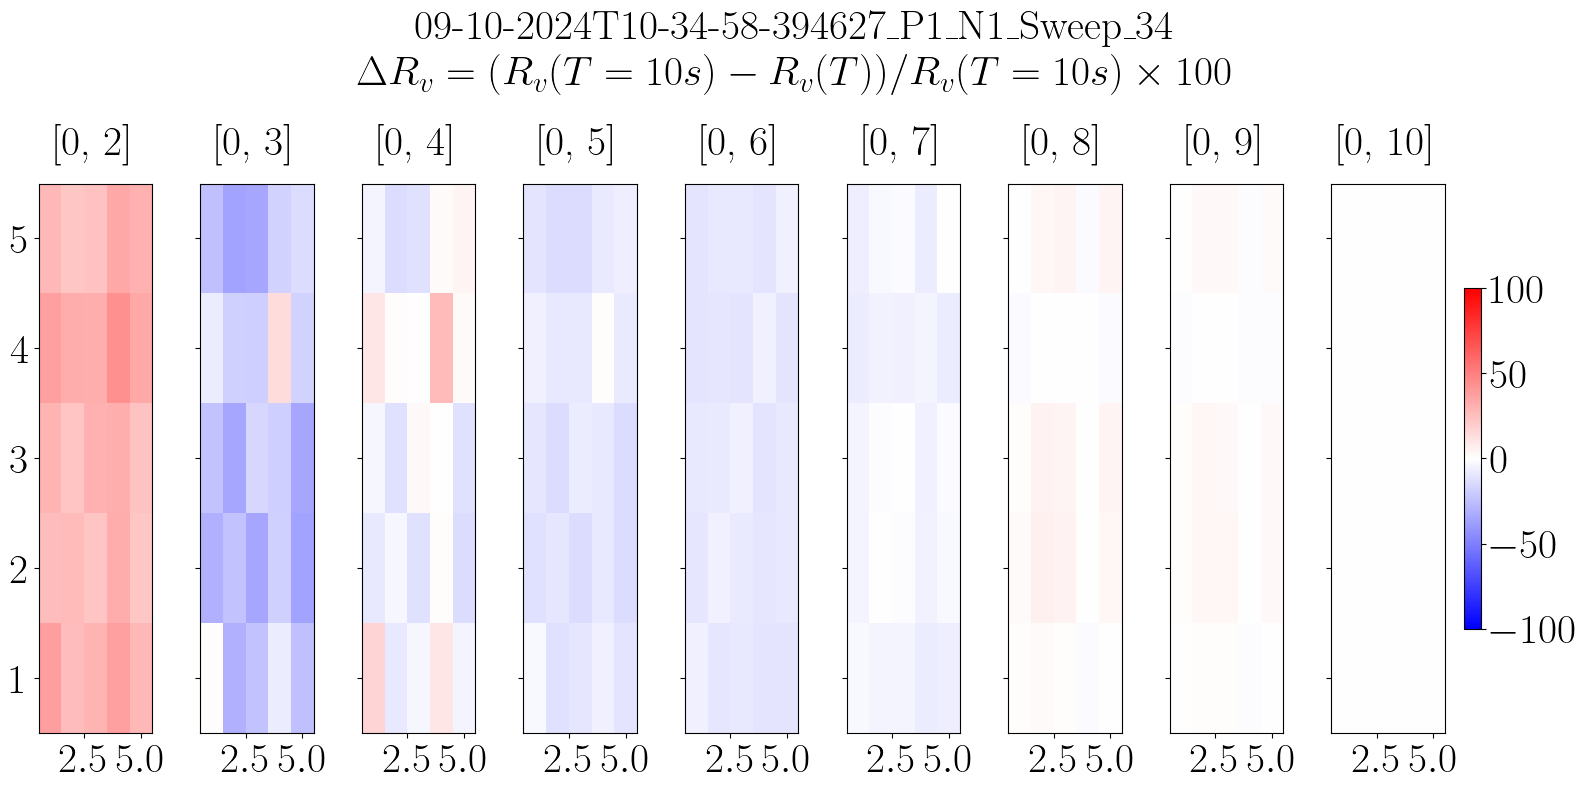

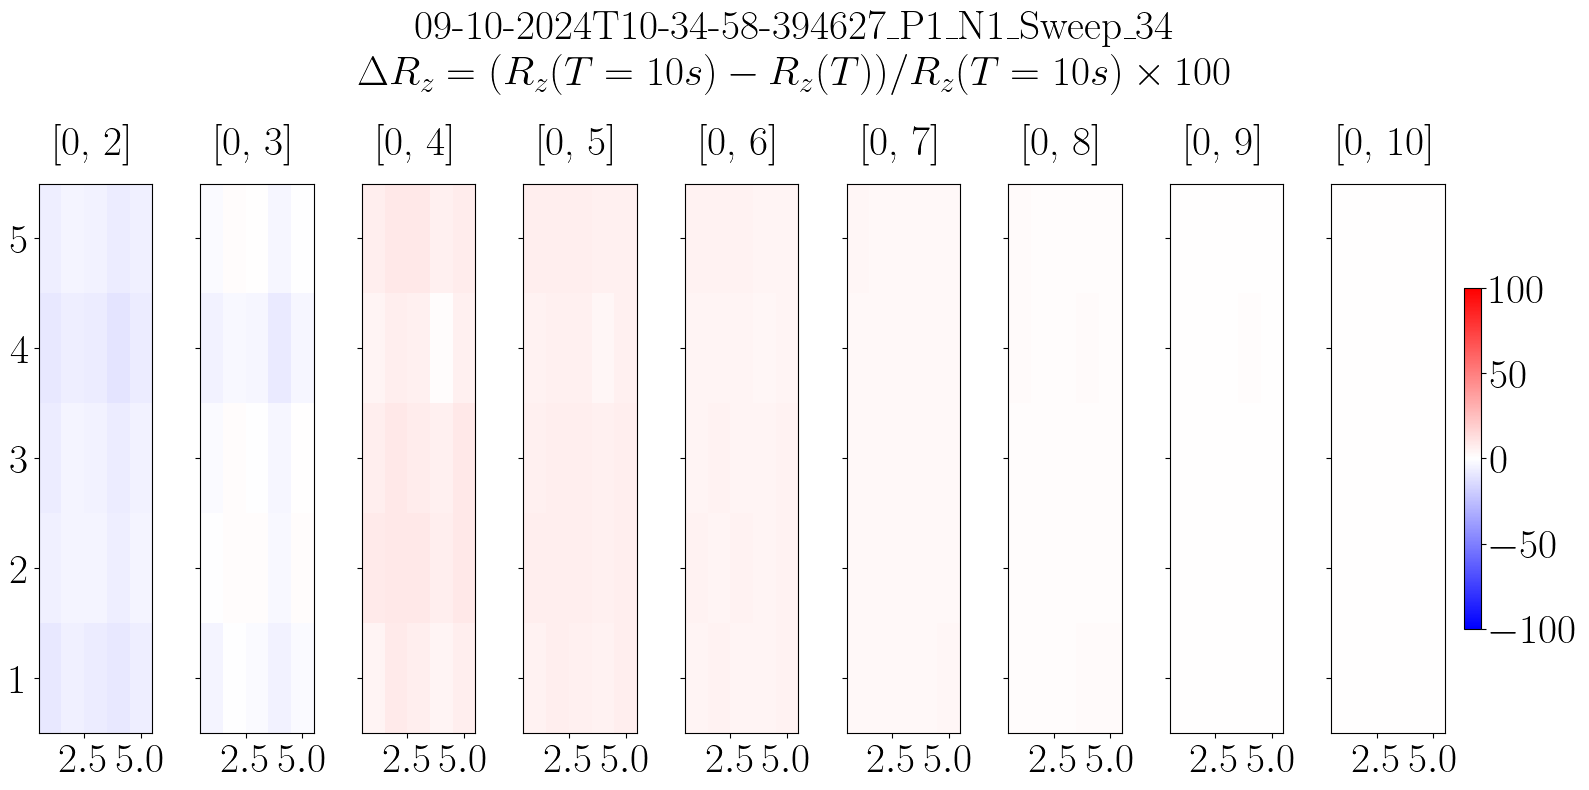

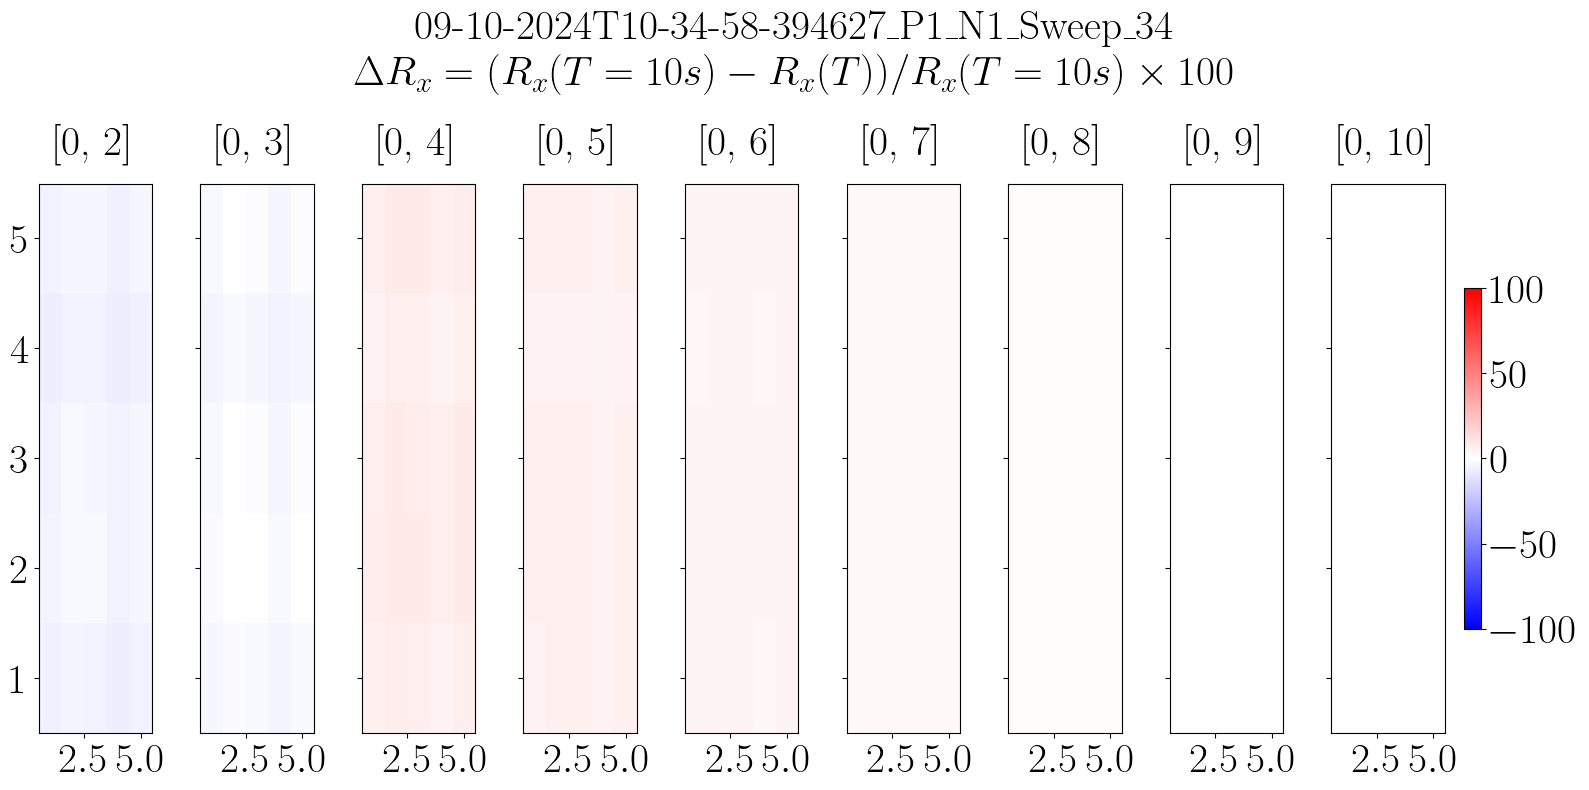

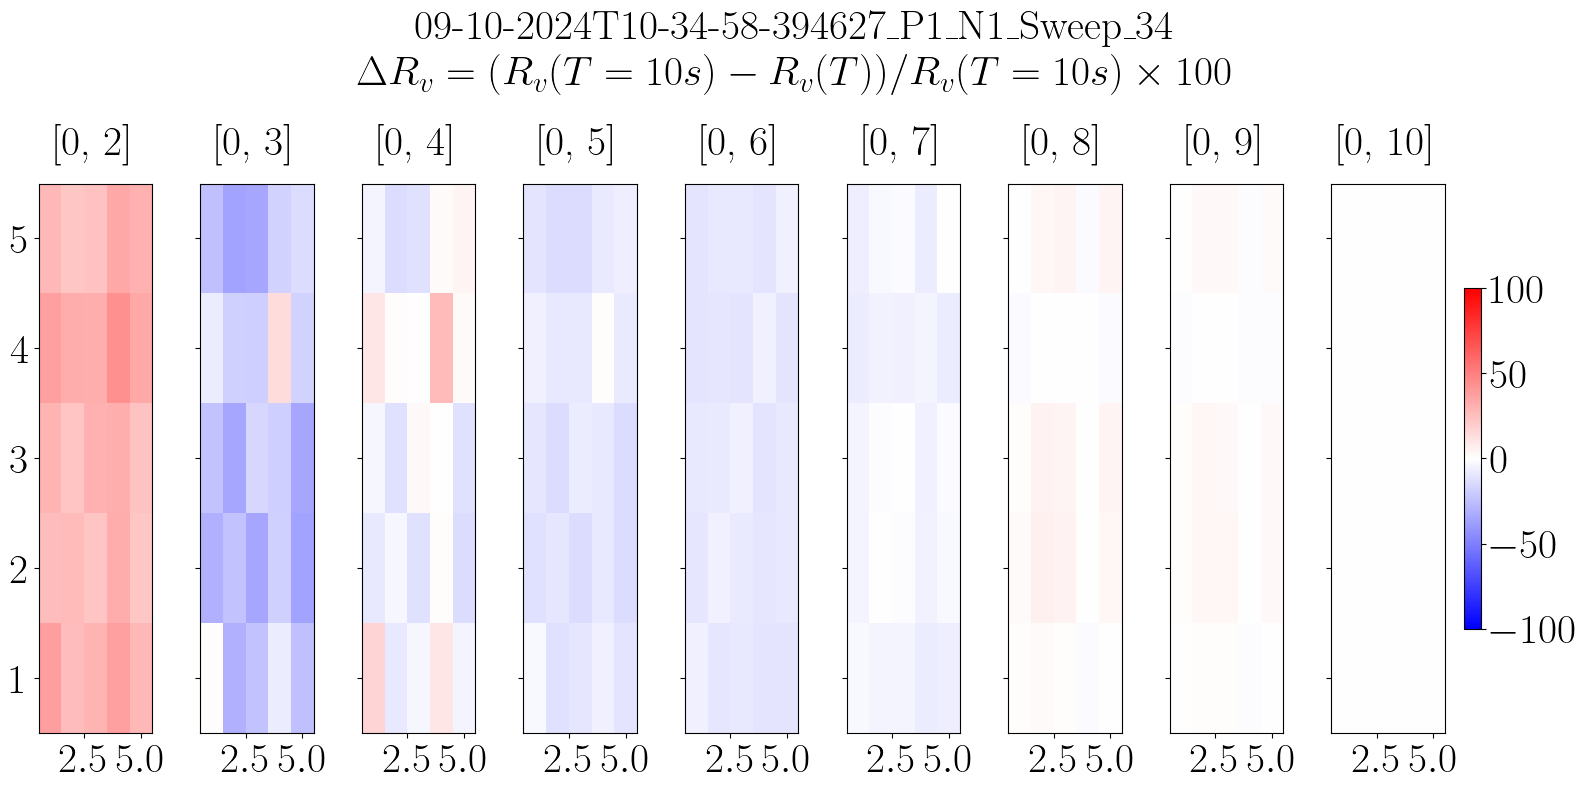

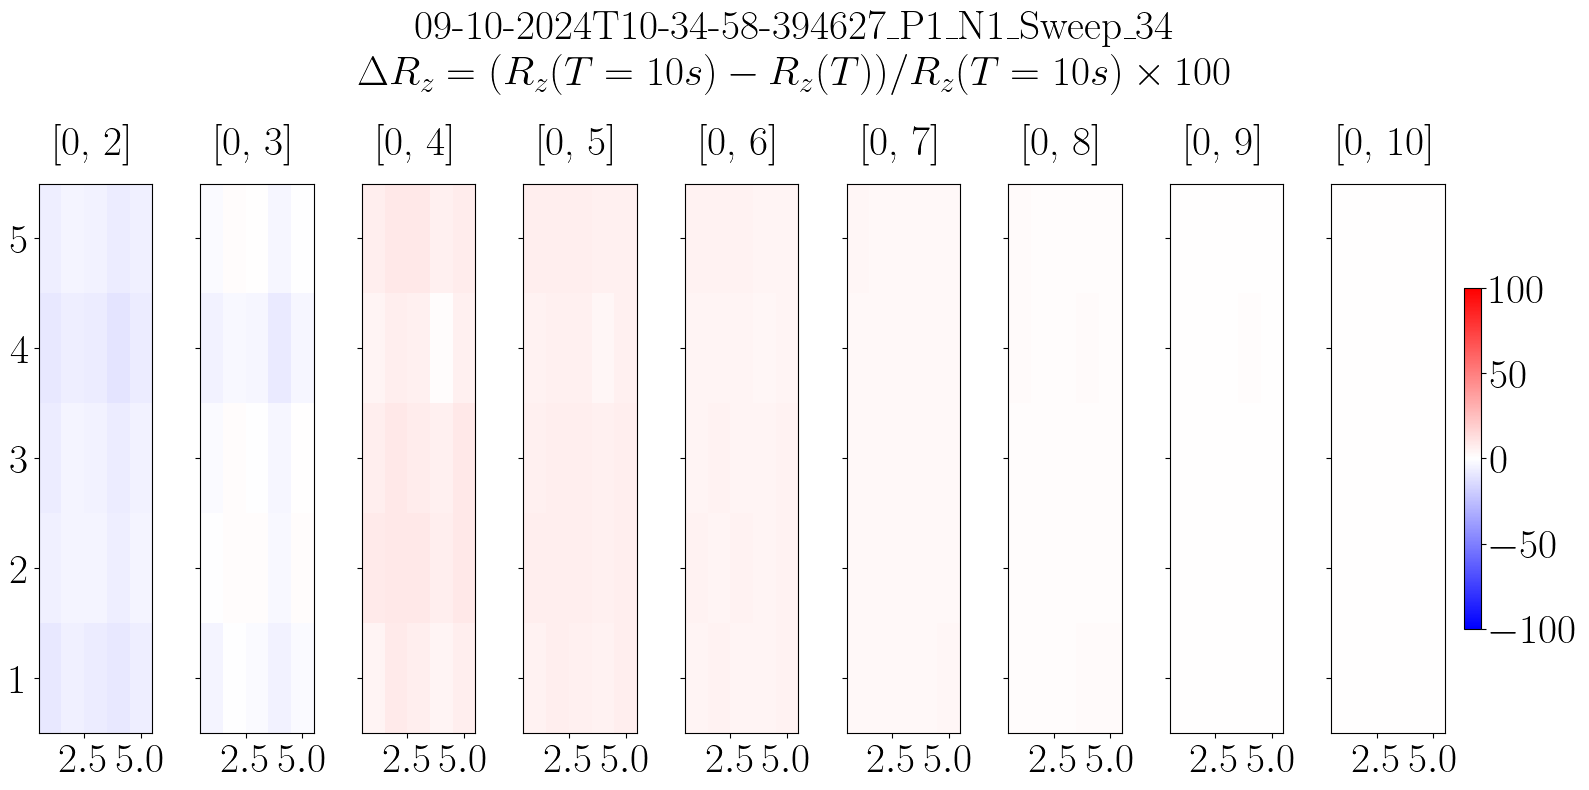

In [14]:
verbose = False
# Plot results
n_win = len(Tw)

# Select a band to plot the estimated rtfs
fmin = 11000
fmax = 12000

if plot_tw_slice_rtf_results:
    for rtf_e in rtf_estimators:

        # Iterate over recordings
        show_plot = True
        for recording_name in static_records:
            # Iterate over slices

            for i_slice in range(n_win):
                ds_rtf = results[rtf_e][recording_name][i_slice]

                if i_slice == 0:
                    # nl = ds_rtf.sizes["h_index"]
                    nl = 2  # Plot only first 2 receivers

                    # dRx matrix
                    fig_drx, axs_drx = plt.subplots(1, n_win, sharey=True)
                    fig_drx.suptitle(
                        f"{recording_name} \n "
                        + r"$\Delta R_x = (R_x(T=10s) - R_x(T)) / R_x(T=10s) \times 100$"
                    )
                    # dRv matrix
                    fig_drv, axs_drv = plt.subplots(1, n_win, sharey=True)
                    fig_drv.suptitle(
                        f"{recording_name} \n "
                        + r"$\Delta R_v = (R_v(T=10s) - R_v(T)) / R_v(T=10s) \times 100$"
                    )
                    # dRz matrix
                    fig_drz, axs_drz = plt.subplots(1, n_win, sharey=True)
                    fig_drz.suptitle(
                        f"{recording_name} \n "
                        + r"$\Delta R_z = (R_z(T=10s) - R_z(T)) / R_z(T=10s) \times 100$"
                    )

                # f_csdm = fmin
                f_csdm = slice(fmin, fmax)
                add_colorbar = i_slice == n_win - 1  # Add colorbar only for last subplot
                cbar_kwargs = dict(label=r"% error") if add_colorbar else None
                dr_vmin = -100
                dr_vmax = 100

                r_title = f"[0, {Tw[i_slice]}]"

                # Plot dRx
                ds_rtf_10s = results[rtf_e][recording_name][-1]
                # rx_ref = ds_rtf_10s.sel(f_csdm=f_csdm, method="nearest").Rx
                rx_ref = ds_rtf_10s.sel(f_csdm=f_csdm).Rx
                rx = ds_rtf.sel(f_csdm=f_csdm).Rx  # Frequency slice
                drx = (rx_ref - rx) / rx_ref * 100  # Relative difference in %
                drx = drx.mean(dim="f_csdm")  # Mean over frequency slice
                drx.plot(
                    ax=axs_drx[i_slice],
                    label=rf"t $\in$ [0, {Tw[i_slice]}]s",
                    cmap="bwr",
                    vmin=dr_vmin,
                    vmax=dr_vmax,
                    add_colorbar=add_colorbar,
                    cbar_kwargs=cbar_kwargs,
                )
                axs_drx[i_slice].set_xlabel("")
                axs_drx[i_slice].set_ylabel("")
                axs_drx[i_slice].set_title(r_title)

                # Plot dRv
                # rv_ref = ds_rtf_10s.sel(f_csdm=f_csdm, method="nearest").Rv
                rv_ref = ds_rtf_10s.sel(f_csdm=f_csdm).Rv
                rv = ds_rtf.sel(f_csdm=f_csdm).Rv  # Frequency slice
                drv = (rv_ref - rv) / rv_ref * 100  # Relative difference in %
                drv = drv.mean(dim="f_csdm")  # Mean over frequency slice
                drv.plot(
                    ax=axs_drv[i_slice],
                    # label=rf"t $\in$ [0, {Tw[i_slice]}]s",
                    cmap="bwr",
                    vmin=dr_vmin,
                    vmax=dr_vmax,
                    add_colorbar=add_colorbar,
                    cbar_kwargs=cbar_kwargs,
                )
                axs_drv[i_slice].set_xlabel("")
                axs_drv[i_slice].set_ylabel("")
                axs_drv[i_slice].set_title(r_title)

                # Plot dRz
                rz_ref = rx_ref - rv_ref
                rz = rx - rv
                drz = (rz_ref - rz) / rz_ref * 100  # Relative difference in %
                drz = drz.mean(dim="f_csdm")  # Mean over frequency slice
                drz.plot(
                    ax=axs_drz[i_slice],
                    # label=rf"t $\in$ [0, {Tw[i_slice]}]s",
                    cmap="bwr",
                    vmin=dr_vmin,
                    vmax=dr_vmax,
                    add_colorbar=add_colorbar,
                    cbar_kwargs=cbar_kwargs,
                )
                axs_drz[i_slice].set_xlabel("")
                axs_drz[i_slice].set_ylabel("")
                axs_drz[i_slice].set_title(r_title)

                # Print a few infos
                if verbose:
                    print(f"Record: {recording_name}, slice: t c [0, {Tw[i_slice]}]s")
                    print(
                        f"max mean_dRx = {drx.max().values:.2f}%, max mean_dRv = {drv.max().values:.2f}%, max mean_dRz = {drz.max().values:.2f}%"
                    )
                    print(
                        f"min mean_dRx = {drx.min().values:.2f}%, min mean_dRv = {drv.min().values:.2f}%, min mean_dRz = {drz.min().values:.2f}%"
                    )

            # Save
            pos_id = recording_name.split("_")[1]
            fig_drx.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_dRx_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            fig_drv.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_dRv_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )
            fig_drz.savefig(
                os.path.join(
                    csdm_subfolders[rtf_e][recording_name],
                    f"{pos_id}_dRz_vs_Tslice.png",
                ),
                dpi=300,
                bbox_inches="tight",
            )

            if show_plot:
                plt.show()
                show_plot = False
                
            plt.close("all")

## Variation de l'angle hermitien en fonction de la durée du signal 

In [15]:
# Compute theta for each slice
fmin = fs_sweep.fmin
fmax = fs_sweep.fmax
# fmin = 11900
# fmax = 12000

thetas = {rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators}
d_frobenius_mod = {
    rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators
}
d_frobenius = {rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators}

# Progress bar 
index = 0
prev_progress = 0
n_iter = len(rtf_estimators) * len(static_records) * n_win

for rtf_e in rtf_estimators:

    # Iterate over recordings
    for recording_name in static_records:
        # Iterate over slices
        # theta_slice = []
        for i_slice in range(n_win):

            prev_progress = progression_bar(index=index, index0=0, indexf=n_iter-1, prev_progress=prev_progress)
            index += 1
            
            ds_rtf = results[rtf_e][recording_name][i_slice]
            # nl = ds_rtf.sizes["h_index"]

            # Select frequency band
            ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
            ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

            # Extract RTF ref (from deconvolution)
            rtf_ref_mod = ds_rtf.rtf_amp
            rtf_ref_phase = ds_rtf.rtf_phase
            # Extract RTF hat (from CS-EVD)
            rtf_hat_mod = ds_rtf.rtf_amp_hat
            rtf_hat_phase = ds_rtf.rtf_phase_hat

            # Interp RTF ref at RTF hat frequencies (nearest neigbor)
            rtf_ref_mod = rtf_ref_mod.sel(
                f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
            )
            rtf_ref_phase = rtf_ref_phase.sel(
                f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
            )

            # Build rtfs
            rtf_ref = rtf_ref_mod * np.exp(1j*rtf_ref_phase)
            rtf_hat = rtf_hat_mod * np.exp(1j*rtf_hat_phase)

            # Compute mean theta distance over the frequency band of interest
            theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)
            thetas[rtf_e][recording_name].append(theta)

            # Compute frobenius distance
            delta_pi = rtf_ref.values - rtf_hat.values
            df = np.sqrt(np.sum(np.abs(delta_pi)**2))
            d_frobenius[rtf_e][recording_name].append(df)

            # Compute frobenius distance using only module
            delta_pi = rtf_ref_mod.values - rtf_hat_mod.values
            df_mod = np.sqrt(np.sum(np.abs(delta_pi) ** 2))
            d_frobenius_mod[rtf_e][recording_name].append(df_mod)

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

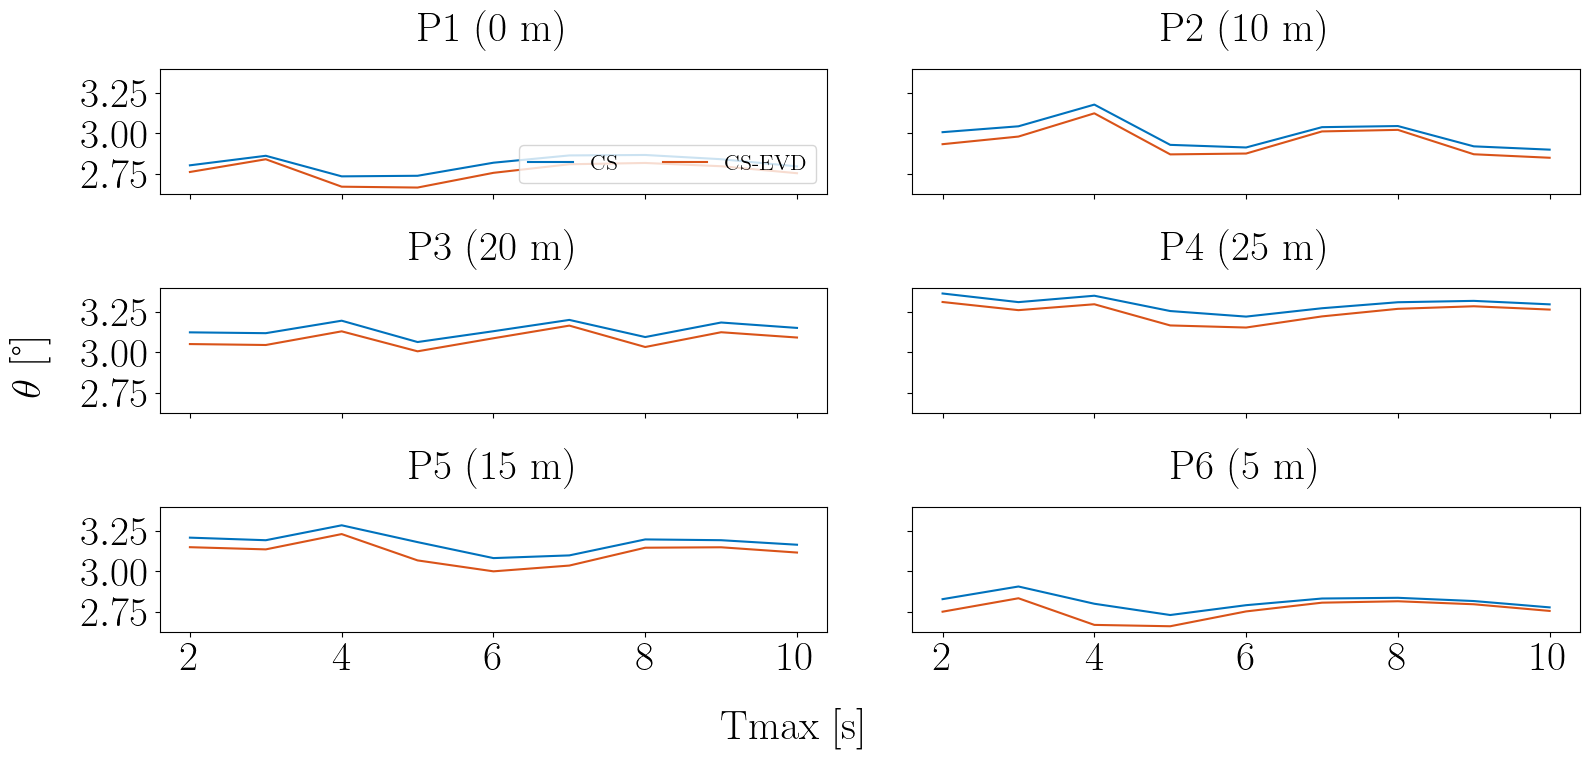

In [16]:
# Distance theta 
fig, axs = plt.subplots(3, 2, sharex=True, sharey=True)
fig.suptitle(f"")
for j, recording_name in enumerate(static_records):
    ax = axs[j // 2, j % 2]
    pos_id = recording_name.split("_")[1]
    for i, rtf_e in enumerate(rtf_estimators):
        ax.plot(Tw, thetas[rtf_e][recording_name], label=rtf_e.upper(), color=color(i))
        
    ax.set_title(f"{pos_id} ({dict_th_pos[pos_id]} m)")
    if j == 0:
        ax.legend(fontsize=16, loc="lower right", ncols=2)
fig.supxlabel("Tmax [s]")
fig.supylabel(r"$\theta$ [°]")

# Save 
fpath = os.path.join(rtf_folder, "theta_vs_duration.png")
plt.savefig(fpath)

In [17]:
# # Distance de frobenius
# df_max = np.max([np.max(d_frobenius[rtf_e][rec]) for rtf_e in rtf_estimators for rec in static_records])
# fig, axs = plt.subplots(3, 2, sharex=True)
# fig.suptitle(f"Distance de frobenius normalisée")
# for j, recording_name in enumerate(static_records):
#     ax = axs[j // 2, j % 2]
#     pos_id = recording_name.split("_")[1]
#     for i, rtf_e in enumerate(rtf_estimators):
#         ax.plot(
#             Tw,
#             d_frobenius[rtf_e][recording_name] / df_max,
#             label=rtf_e.upper(),
#             color=color(i),
#         )

#     ax.set_title(pos_id)
#     if j == 0:
#         ax.legend(fontsize=16, loc="upper right", ncols=2)
# fig.supxlabel("Tmax [s]")

In [18]:
# # Distance de frobenius
# df_max = np.max(
#     [
#         np.max(d_frobenius_mod[rtf_e][rec])
#         for rtf_e in rtf_estimators
#         for rec in static_records
#     ]
# )
# fig, axs = plt.subplots(3, 2, sharex=True)
# fig.suptitle(f"Distance de frobenius sur le module uniquement normalisée")
# for j, recording_name in enumerate(static_records):
#     ax = axs[j // 2, j % 2]
#     pos_id = recording_name.split("_")[1]
#     for i, rtf_e in enumerate(rtf_estimators):
#         ax.plot(
#             Tw,
#             d_frobenius_mod[rtf_e][recording_name] / df_max,
#             label=rtf_e.upper(),
#             color=color(i),
#         )

#     ax.set_title(pos_id)
#     if j == 0:
#         ax.legend(fontsize=16, loc="upper right", ncols=2)
# fig.supxlabel("Tmax [s]")

# BILAN 

## Rappel de l'objectif 
L'objectif du notebook est d'étudier les performances des deux estimateurs de RTF CS et CS-EVD pour des signaux de tailles variables. En particulier on souhaitait étudier l'influence de la durée du signal sur les performances des estimateurs.

## Démarche suivie 
Pour ce faire, on étudie les signaux des enregistrements en statique aux positions P1 à P6. Pour chacun des enregistrements les grandeurs d'intérêt (le vecteur de RTF ainsi que les matrices de covariance dont le calcul est nécessaire à son estimation) sont estimées pour des portions du signal de durée croissante. Les grandeurs d'intérêt ainsi estimées sont comparées aux grandeurs estimées sur l'intégralité du signal (cas le plus favorable). 

Afin de pouvoir comparer les résultats une étude préalable est menée pour définir les paramètres STFT optimaux dans le cas de la plus courte portion de signal à étudier (ici 2s). Ce cas représente, a priori, le cas le plus défavorable avec un nombre minimum de snapshots L disponibles pour l'estimation des matrices de covariance.  
Les paramètres optimaux retenus sont (obtenus pour la méthode CS-EVD et utilisés dans la suite indifféremment pour CS et CS-EVD) : 

$$ n_{stft} = 2^{15}, \quad \alpha_{ov} = 0.75 $$

## Résultats 

### Etude des matrices de covariance 
Pour les deux méthodes considérées, l'estimation des vecteurs de RTF repose sur l'analyse de la matrice de covariance du signal d'intérêt $R_z$ estimée par : 

$$ \hat{R}_z = \hat{R}_x - \hat{R}_v  $$ 

L'étude montre de faibles variations de la matrice $\hat{R}_z $ en fonction de la durée du signal utilisé. 

#### Erreurs d'estimation de la matrice de covariance du bruit

Les variations les plus importantes sont observées sur la matrice de covariance du bruit $\hat{R}_v$. Ces variations (par rapport à la matrice de covariance du bruit calculée pour le signal complet de 10 s) sont dues à la faible robustesse de la méthode de segmentation utilisée pour définir les périodes de bruit + signal et les périodes de bruit. En effet, cette étape de segmentation est basée sur un simple détecteur d'énergie dans la bande de fréquence du signal (fonction get_signal_presence_mask()). Plus précisément, un segment de STFT est classé comme signal + bruit si : 

$$ E(l) >= threshold $$
où 
$$ E(l) = \int_0^{fs/2} \lvert X(l, f) \rvert^2  df \quad \text{et}  \quad threshold = 0.3  min_{peaks} $$

avec $min_{peaks}$ le minimum des pics détecté dans le vecteur d'énergie en fonction du temps $E(t)$. 

Ainsi, il arrive que certains des segments contenant du signal et du bruit soit classifiés par erreur comme segment de bruit en raison d'un niveau d'énergie plus faible que le seuil ainsi défini. 
La matrice de covariance du bruit est estimée par :

$$  \hat{R}_v(k)  = \frac{1}{L_v} \sum_{l=1}^{L_v} V(l, k)V^H(l, k) $$

Si l'on note $L_v'$ les segments ne contenant vraiment que du bruit et $L_v"$ les segments mal classifiés contenant du signal + bruit tel que :

$$ L_v = L_v' + L_v" $$

On peut écrire, 

$$  \hat{R}_v(k)  = \frac{1}{L_v} \sum_{l'=1}^{L_v'} V(l', k)V^H(l', k) + \frac{1}{L_v} \sum_{l"=1}^{L_v"} X(l", k)X^H(l", k)$$

et avec des notations évidentes : 

$$  \hat{R}_v(k)  = \hat{R}'_v(k) + \hat{R}_v"(k) $$

Notons $L_{v1}$ le nombre de segments contenus dans 1 s de signal (i.e pour 1 chirp) : 

$$ L_{v1} = L_{v1}' + L_{v1}" $$

pour un signal de $n$ secondes : 

$$ L_{vn} = L_{vn}' + L_{vn}" =  n L_{v1}' + n L_{v1}"$$

##### Cas des signaux courts 
L'erreur de segmentation conduit généralement à une mauvaise classification de 1 à 2 segments par chirp (ie pour 1s de signal), typiquement un segment de part et autre du pic d'énergie. Dans le cas où le signal considéré est court $L_v'$ et $L_v"$ sont du même ordre de grandeur.   

Dans le cas des signaux du bassin, le SNR est très élevé et on peut donc écrire, pour les coefficients diagonaux : 

$$\lvert \hat{R}'_v(k)[i, i] \rvert \ll \lvert \hat{R}_v"(k)[i, i] \rvert \,, \forall i $$

De plus, la gamme de fréquence à laquelle on travaille est de l'ordre de 10 kHz correspondant à une longueur de d'onde $\lambda = \frac{c_0}{f} = 15 cm$. La distance intercapteurs est d'environ 3 m  soit 20 fois la longueur d'onde. Cette distance est grande devant la distance cohérénce caractéristique du bruit (ici ce n'est pas le bruit ambiant marin mais le raissonnement est probablement valable). Ainsi, l'inégalité ci-dessus est vrai pour l'ensemble des coefficients,  

$$\lvert \hat{R}'_v(k)[i, j] \rvert \ll \lvert \hat{R}_v"(k)[i, j] \rvert \,, \forall (i, j) $$

et dans ce cas, 

$$  \hat{R}_v(k)  \approx \hat{R}_v"(k) \approx \hat{R}_x $$

Ceci explique que la matrice de covariance du bruit ait une structure identique à celle de la matrice de covariance signal + bruit. Compte tenu du très fort SNR ceci ne semble pas conduire à des erreurs importantes dans notre cas. 

##### Cas des signaux long 

Lorsque la durée du signal augmente, le nombre de segments ne contenant que du bruit $L_v'$ devient grand devant le nombre de segments mal classifiés $L_v"$ : 

$$ \frac{L_{v}'}{L_{v}} \rightarrow 1 $$ 

et

$$ \frac{L_{v}"}{L_{v}} \rightarrow 0 $$ 

et donc, 

$$  \hat{R}_v  \rightarrow  R_v $$

##### Amélioration 

On peut aisément améliorer les choses en excluant les segments adjacents aux segments identifiés comme signal plus bruit ou bien implémenter une autre méthode de détection plus précise. 

### Erreurs d'estimation du vecteur de RTF 

La répercussion de ces erreurs d'estimation sur l'estimation du vecteur de RTF est étudié en observant l'angle hermitien moyen sur la bande du signal en fonction de la durée du signal utilisé. Aucune tendance n'est clairement identifiable et l'allure des très faibles variations observables dépend de la position considérée. En accord avec la littérature et nos précédentes simulations l'estimateur CS-EVD présente des performances légèrement supérieures à l'estimateur CS.



